In [1]:
# -*- coding: utf-8 -*-
"""
Notebook con el fin de procesar tanto los resultados de las pruebas de clasificacion y segmentacion, como la base de datos de embarcaciones
y generar estadisticas y graficas de los resultados obtenidos.
Actualizado: 13 de octubre de 2025
"""
# ---------------- Librerias -------------------------------------------------------------------------------
# Librerias matematicas
import numpy as np
import math
import statistics as stats

# Librerias graficas
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Librerias de manejo de datos
import csv
import os
from datetime import datetime
import re
import pandas as pd
from collections import defaultdict, Counter

# Librerias de manejo de datos geoespaciales
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from pyproj import Transformer

# Librerias de YOLO y OpenCV
import shutil
from ultralytics import YOLO
import cv2

# ---------------- Funciones -------------------------------------------------------------------------------
def xywh_to_xyxy(box: list) -> list:
    """
    Convierte el formato de yolo (x_center, y_center, width, height) a (x_min, y_min, x_max, y_max).

    Args:
        box (list): Lista que contiene las coordenadas de la caja en formato (x_center, y_center, width, height).

    Returns:
        list: Retorna una lista con las coordenadas en el formato (x_min, y_min, x_max, y_max).
    """
    x, y, w, h = box    # Desempaquetar las coordenadas
    x_min = x - w / 2   # Calcular las coordenadas minimas y maximas
    y_min = y - h / 2
    x_max = x + w / 2
    y_max = y + h / 2

    return [x_min, y_min, x_max, y_max] # Retornar las coordenadas en el nuevo formato

def IoU(boxA: list, boxB: list) -> float:
    """
    Calcula el Intersection over Union (IoU) entre dos cajas.

    Args:
        boxA (list): Lista que contiene las coordenadas de la caja A en formato (x_center, y_center, width, height).
        boxB (list): Lista que contiene las coordenadas de la caja B en formato (x_center, y_center, width, height).

    Returns:
        float: Retorna el valor del IoU entre las dos cajas.
    """

    boxA = xywh_to_xyxy(boxA)   # Convertir las cajas al formato (x_min, y_min, x_max, y_max)
    boxB = xywh_to_xyxy(boxB)
   
    xA = max(boxA[0], boxB[0])  # Calcular las coordenadas del area de interseccion
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)                   # Calcular el area de interseccion
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])            # Calcular el area de ambas cajas
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])            
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-9) # Calcular el IoU
    
    return iou

def extract_number(value: str) -> float:
    """
    Extrae un número de un string.

    Args:
        value (str): El string del cual se extraerá el número.

    Returns:
        float: El número extraído o None si no se encontró un número.
    """
    match = re.search(r"[-+]?\d+(?:\.\d+)?", value)     # Buscar un patrón numérico en el string
    return float(match.group()) if match else None  # Retornar el número como float o None si no se encontró

def modelo_sort_key(modelo: str, type_order: list, size_order: list) -> tuple:
    """
    Genera una clave de ordenamiento para un modelo basado en su tipo y tamaño.
    
    Args:
        modelo      (str): El nombre del modelo en el formato "Modelo_size_type".
        type_order (list): Lista que define el orden de los tipos.
        size_order (list): Lista que define el orden de los tamaños.
    
    Returns:
        tuple: Una tupla que contiene los índices del tipo y tamaño en sus respectivas listas de orden.
    """
    _, size, tipo = modelo.split("_")                               # Dividir el nombre del modelo para obtener tamaño y tipo   
    return (type_order.index(tipo), size_order.index(int(size)))    # Retornar una tupla con los índices del tipo y tamaño

def Clasification_Results(Ruta_Archivo: str) -> dict:
    """
    Genera un diccionario con los resultados de clasificación a partir de un archivo CSV.

    Args:
        Ruta_Archivo (str): La ruta del archivo CSV de entrada.
    
    Returns:
        dict: Un diccionario con los resultados de clasificación.
    """

    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]       # Extraer el nombre del dispositivo del nombre del archivo
    Model={Nombre_Dispositivo: {}}                                              # Inicializar el diccionario de resultados                              

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:  # Abrir el archivo CSV
        reader = csv.DictReader(infile)                                         # Leer el archivo CSV como un diccionario
        header = reader.fieldnames                                              # Obtener los nombres de las columnas

        # ---------------- Inicializacion de los diccionarios de resultado para cada modelo ----------------

        for header_index in range(len(header)):                                 # Iterar sobre los nombres de las columnas
            model_name = header[header_index].split(' - ')[0]                   # Extraer el nombre del modelo
            Data_type = header[header_index].split(' - ')[-1]                   # Extraer el tipo de dato
            
            if(Data_type == 'prediction'):                                      # Si el tipo de dato es 'prediction', inicializar las métricas
                Model[Nombre_Dispositivo][model_name] = {  
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[]
                    }
        # ---------------- Llenado de la base de datos para cada modelo ------------------------------------
                   
        for row in reader:                                                      # Iterar sobre cada fila del archivo CSV
            for field, column in row.items():                                   # Iterar sobre cada columna de la fila
                model_name = field.split(' - ')[0]                              # Extraer el nombre del modelo
                Data_type = field.split(' - ')[-1]                              # Extraer el tipo de dato
                
                if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', actualizar las métricas
                    if(row['Main_Label']==column):                                      # Si la predicción entre la base de datos y los resultados coinciden
                        if(column=='1'):                                                # Si la predicción es positiva, incrementar el contador de verdaderos positivos
                            Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1     
                        else:                                                           # Si la predicción es negativa, incrementar el contador de verdaderos negativos
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                    else:       
                        if(column=='1'):                                                # Si la predicción es positiva, pero la base de datos es negativa, incrementar el contador de falsos positivos
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:                                                           # Si la predicción es negativa, pero la base de datos es positiva, incrementar el contador de falsos negativos
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1
                
                elif(Data_type == 'conf'):                                              # Si el tipo de dato es 'conf', agregar la probabilidad a la lista
                    Model[Nombre_Dispositivo][model_name]['Probs'].append(float(column))

                elif(Data_type == 'time [ms]'):                                         # Si el tipo de dato es 'time [ms]', agregar el tiempo a la lista
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model

def Segmentation_Results(Ruta_Archivo: str) -> dict:
    """
    Genera un diccionario con los resultados de clasificación a partir de un archivo CSV.

    Args:
        Ruta_Archivo (str): La ruta del archivo CSV de entrada.
    
    Returns:
        dict: Un diccionario con los resultados de segmentacion.
    """

    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]           # Extraer el nombre del dispositivo del nombre del archivo
    Model={Nombre_Dispositivo: {}}                                                  # Inicializar el diccionario de resultados 

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:      # Abrir el archivo CSV
        reader = csv.DictReader(infile)                                             # Leer el archivo CSV como un diccionario
        header = reader.fieldnames                                                  # Obtener los nombres de las columnas

        # ---------------- Inicializacion de los diccionarios de resultado para cada modelo ----------------

        for header_index in range(len(header)):                                     # Iterar sobre los nombres de las columnas
            model_name = header[header_index].split(' - ')[0]                       # Extraer el nombre del modelo
            Data_type = header[header_index].split(' - ')[-1]                       # Extraer el tipo de dato
            
            if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', inicializar las métricas
                Model[Nombre_Dispositivo][model_name] = { 
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[],
                    'IoU':[]
                    }
        
        # ---------------- Llenado de la base de datos para cada modelo ------------------------------------

        for  row in reader:                                                         # Iterar sobre cada fila del archivo CSV
            for field, column in row.items():                                       # Iterar sobre cada columna de la fila
                model_name = field.split(' - ')[0]                                  # Extraer el nombre del modelo
                Data_type = field.split(' - ')[-1]                                  # Extraer el tipo de dato
                
                if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', actualizar las métricas
                    if(row['Main_Label']==column):                                      # Si la predicción entre la base de datos y los resultados coinciden
                        if(column=='0'):                                                # Si la predicción es negativa, incrementar el contador de verdaderos negativos
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                        else:                                                           # Si la predicción es positiva, procesar las segmentaciones
                            # Procesar las segmentaciones de la base de datos
                            DB_Segments = row['Segments']
                            DB_Segments = DB_Segments.strip("[]").split(",")
                            DB_Segments = [item.strip().strip("'").strip('"').strip().split() for item in DB_Segments]   
                            DB_Segments =  [list(map(float,item[1:])) for item in DB_Segments]        
                            
                            # Procesar las segmentaciones de los resultados del modelo
                            YOLO_Segments = row[f"{model_name} - segment"]
                            YOLO_Segments = YOLO_Segments.strip("[]").split(",")
                            YOLO_Segments = [item.strip().strip("'").strip('"').strip().split() for item in YOLO_Segments]   
                            YOLO_Segments =  [list(map(float,item[1:])) for item in YOLO_Segments]        

                            for DB_Segment in DB_Segments:                                          # Calcular el IoU entre cada segmento de la base de datos y los segmentos del modelo
                                for YOLO_Segment in YOLO_Segments:
                                    Model[Nombre_Dispositivo][model_name]['IoU'].append(IoU(DB_Segment, YOLO_Segment))  # Guardar el IoU en el diccionario de resultados

                                    if IoU(DB_Segment, YOLO_Segment) >= 0.5:                        # Si el IoU es mayor o igual a 0.5, considerar que la predicción es correcta
                                        Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1
                                    else:                                                           # Si el IoU es menor a 0.5, considerar que la predicción es incorrecta (falso positivo)
                                        Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1

                    else:   
                        if(column=='1'):                                                            # Si la predicción es positiva, pero la base de datos es negativa, incrementar el contador de falsos positivos
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:                                                                       # Si la predicción es negativa, pero la base de datos es positiva, incrementar el contador de falsos negativos
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1

                elif(Data_type == 'conf'):                                                  # Si el tipo de dato es 'conf', agregar la probabilidad a la lista
                    Conf_List = column
                    Conf_List = [float(x) for x in Conf_List.strip("[]").split(",")]
                    for conf in Conf_List:
                        Model[Nombre_Dispositivo][model_name]['Probs'].append(conf)

                elif(Data_type == 'time [ms]'):                                             # Si el tipo de dato es 'time [ms]', agregar el tiempo a la lista
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model


# Evaluacion de los resultados de los modelos de clasificacion de imagenes

El objetivo del siguiente segmento de codigo es procesar los resultados obtenidos de los modelos de clasificacion de imagenes en diferentes dispositivos (CPU, GPU) y generar estadisticas y graficas de los resultados obtenidos.


Matriz de confusión promedio (promediada en todos los dispositivos):

Resolución                1056                                      \
Tipo                ExtraLarge       Large      Medium       Small   
Embarcación         11.43±0.00  11.52±0.00  11.63±0.00  11.70±0.00   
No Embarcación      87.48±0.00  87.62±0.00  87.77±0.00  87.62±0.00   
Falso Negativo       0.60±0.00   0.52±0.00   0.40±0.00   0.33±0.00   
Falso Positivo       0.49±0.00   0.34±0.00   0.20±0.00   0.34±0.00   
Probabilidad media   0.99±0.05   0.99±0.05   0.99±0.04   0.99±0.04   

Resolución                            832                           \
Tipo                      Nano  ExtraLarge       Large      Medium   
Embarcación         11.61±0.00  11.39±0.00  11.80±0.00  11.81±0.00   
No Embarcación      87.68±0.00  87.62±0.00  87.75±0.00  87.78±0.00   
Falso Negativo       0.43±0.00   0.64±0.00   0.24±0.00   0.23±0.00   
Falso Positivo       0.29±0.00   0.34±0.00   0.21±0.00   0.18±0.00   
Probabilidad media

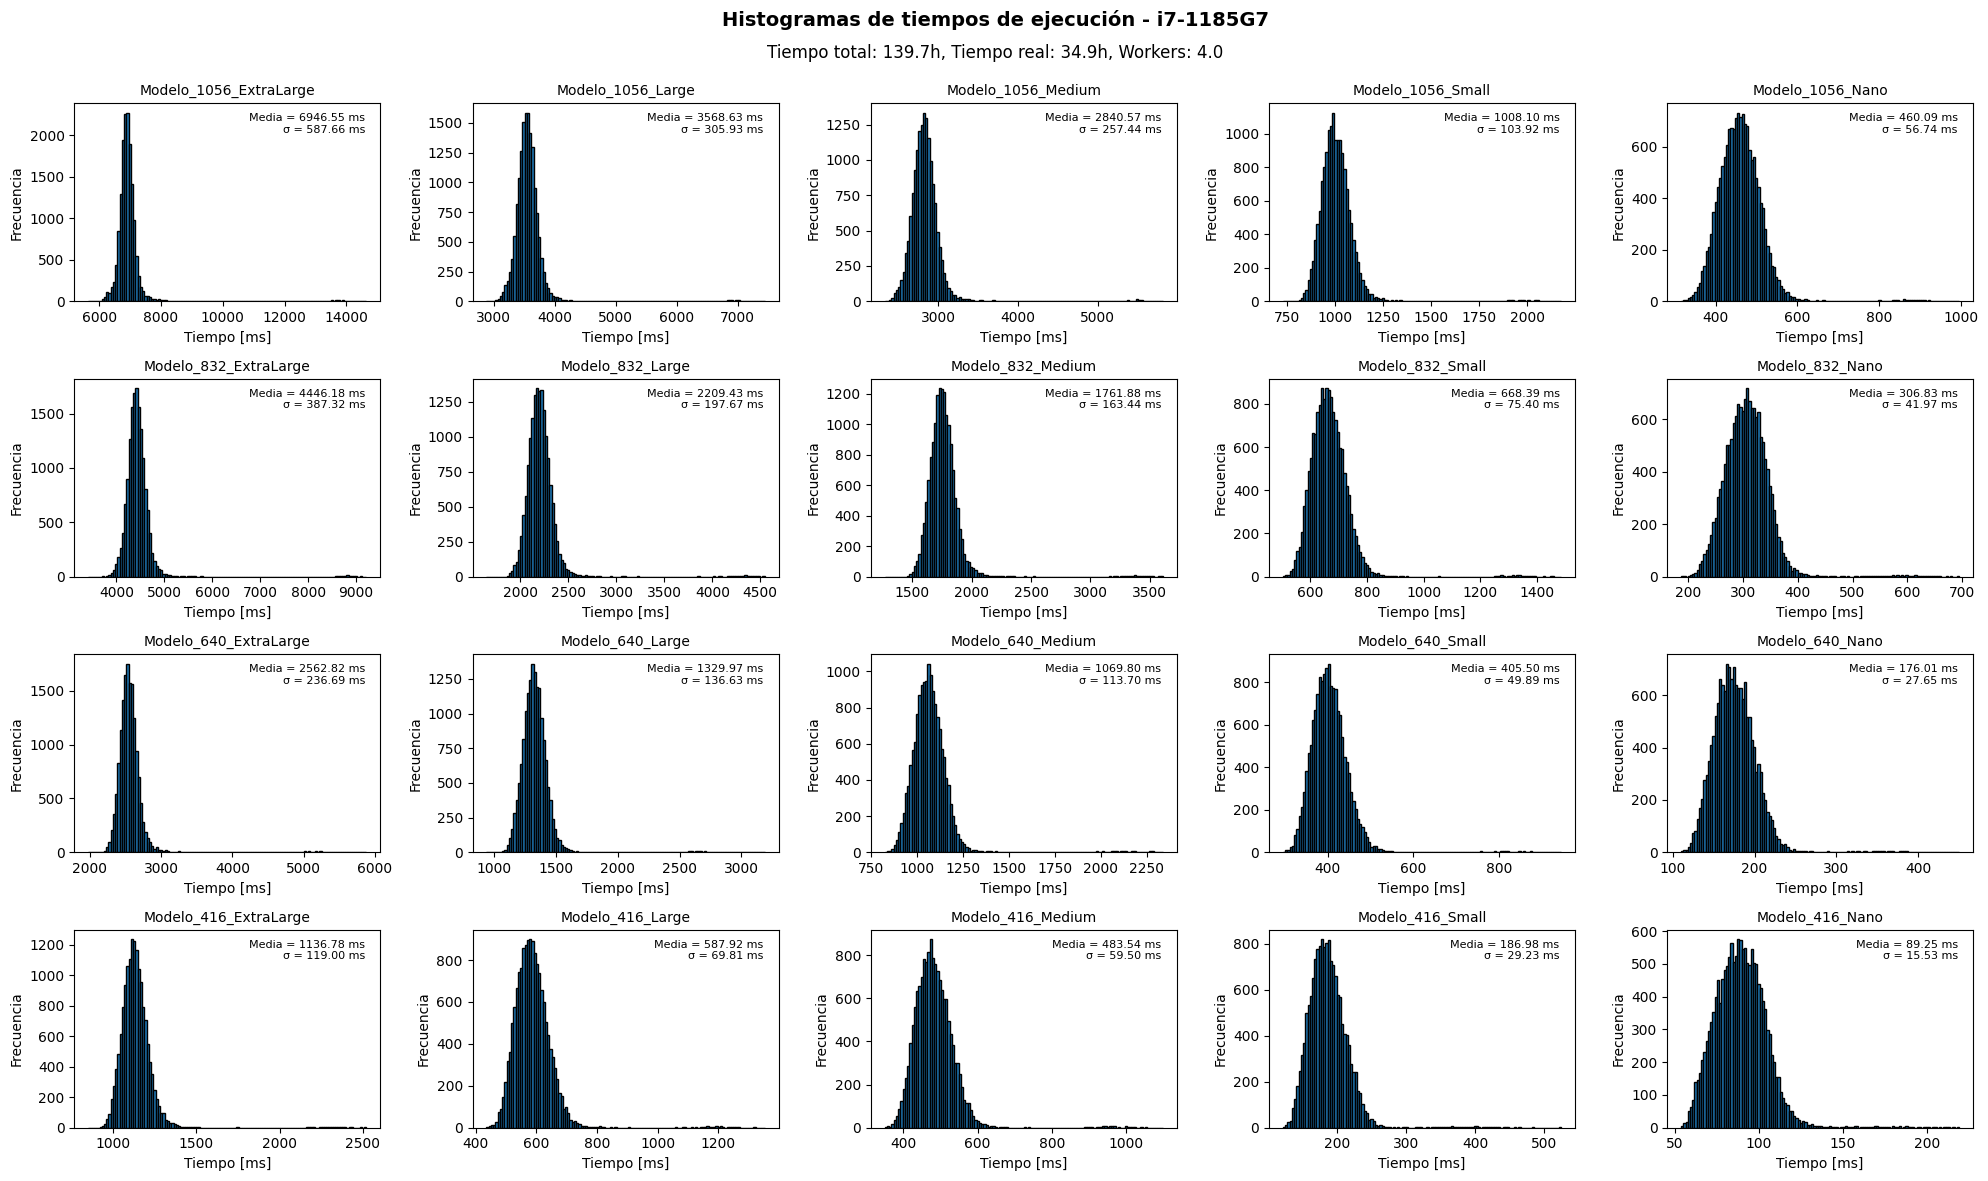

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion:



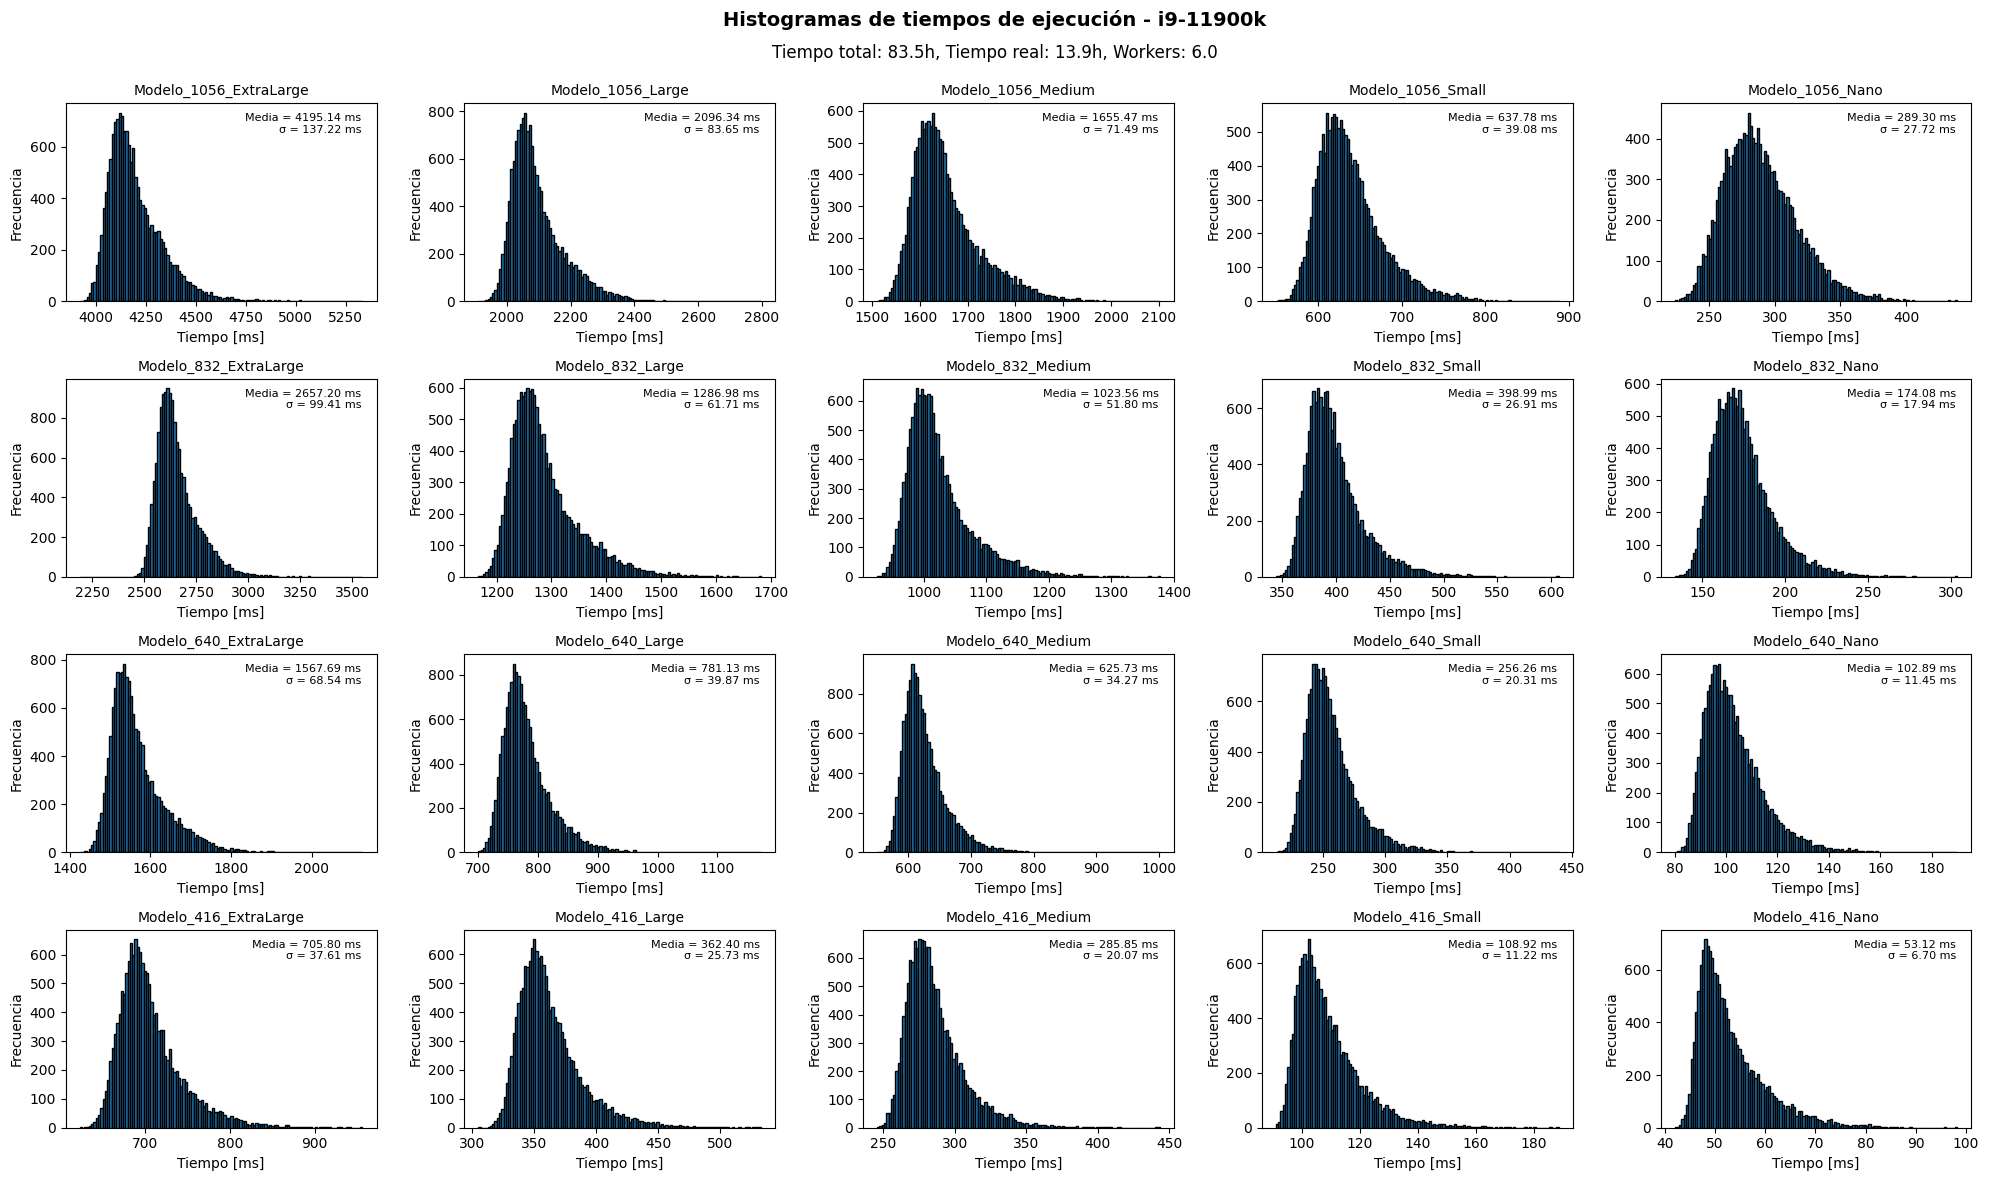

Para el dispositivo RaspberryPi5, se tienen los siguientes tiempos de ejecucion:



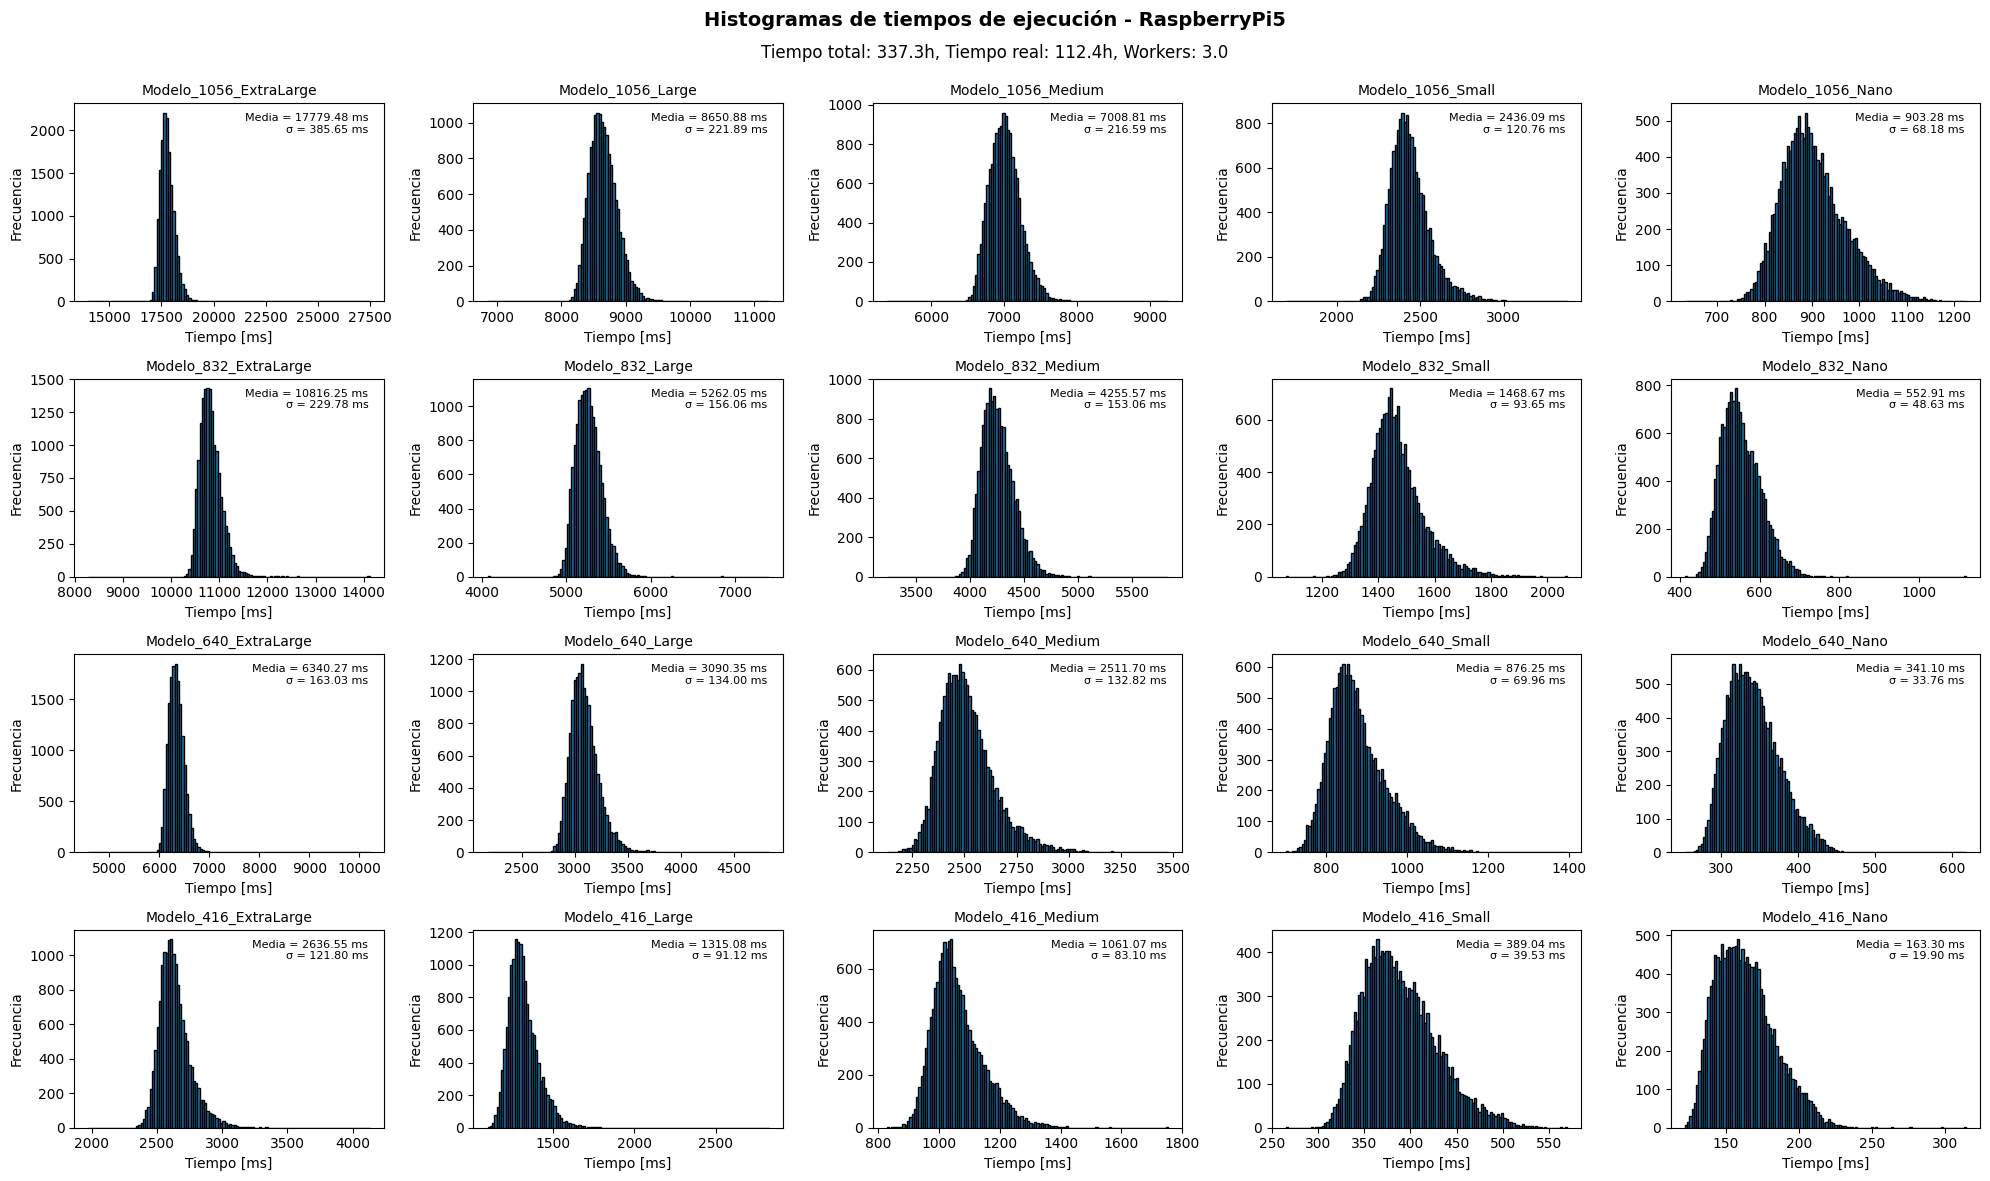

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion:



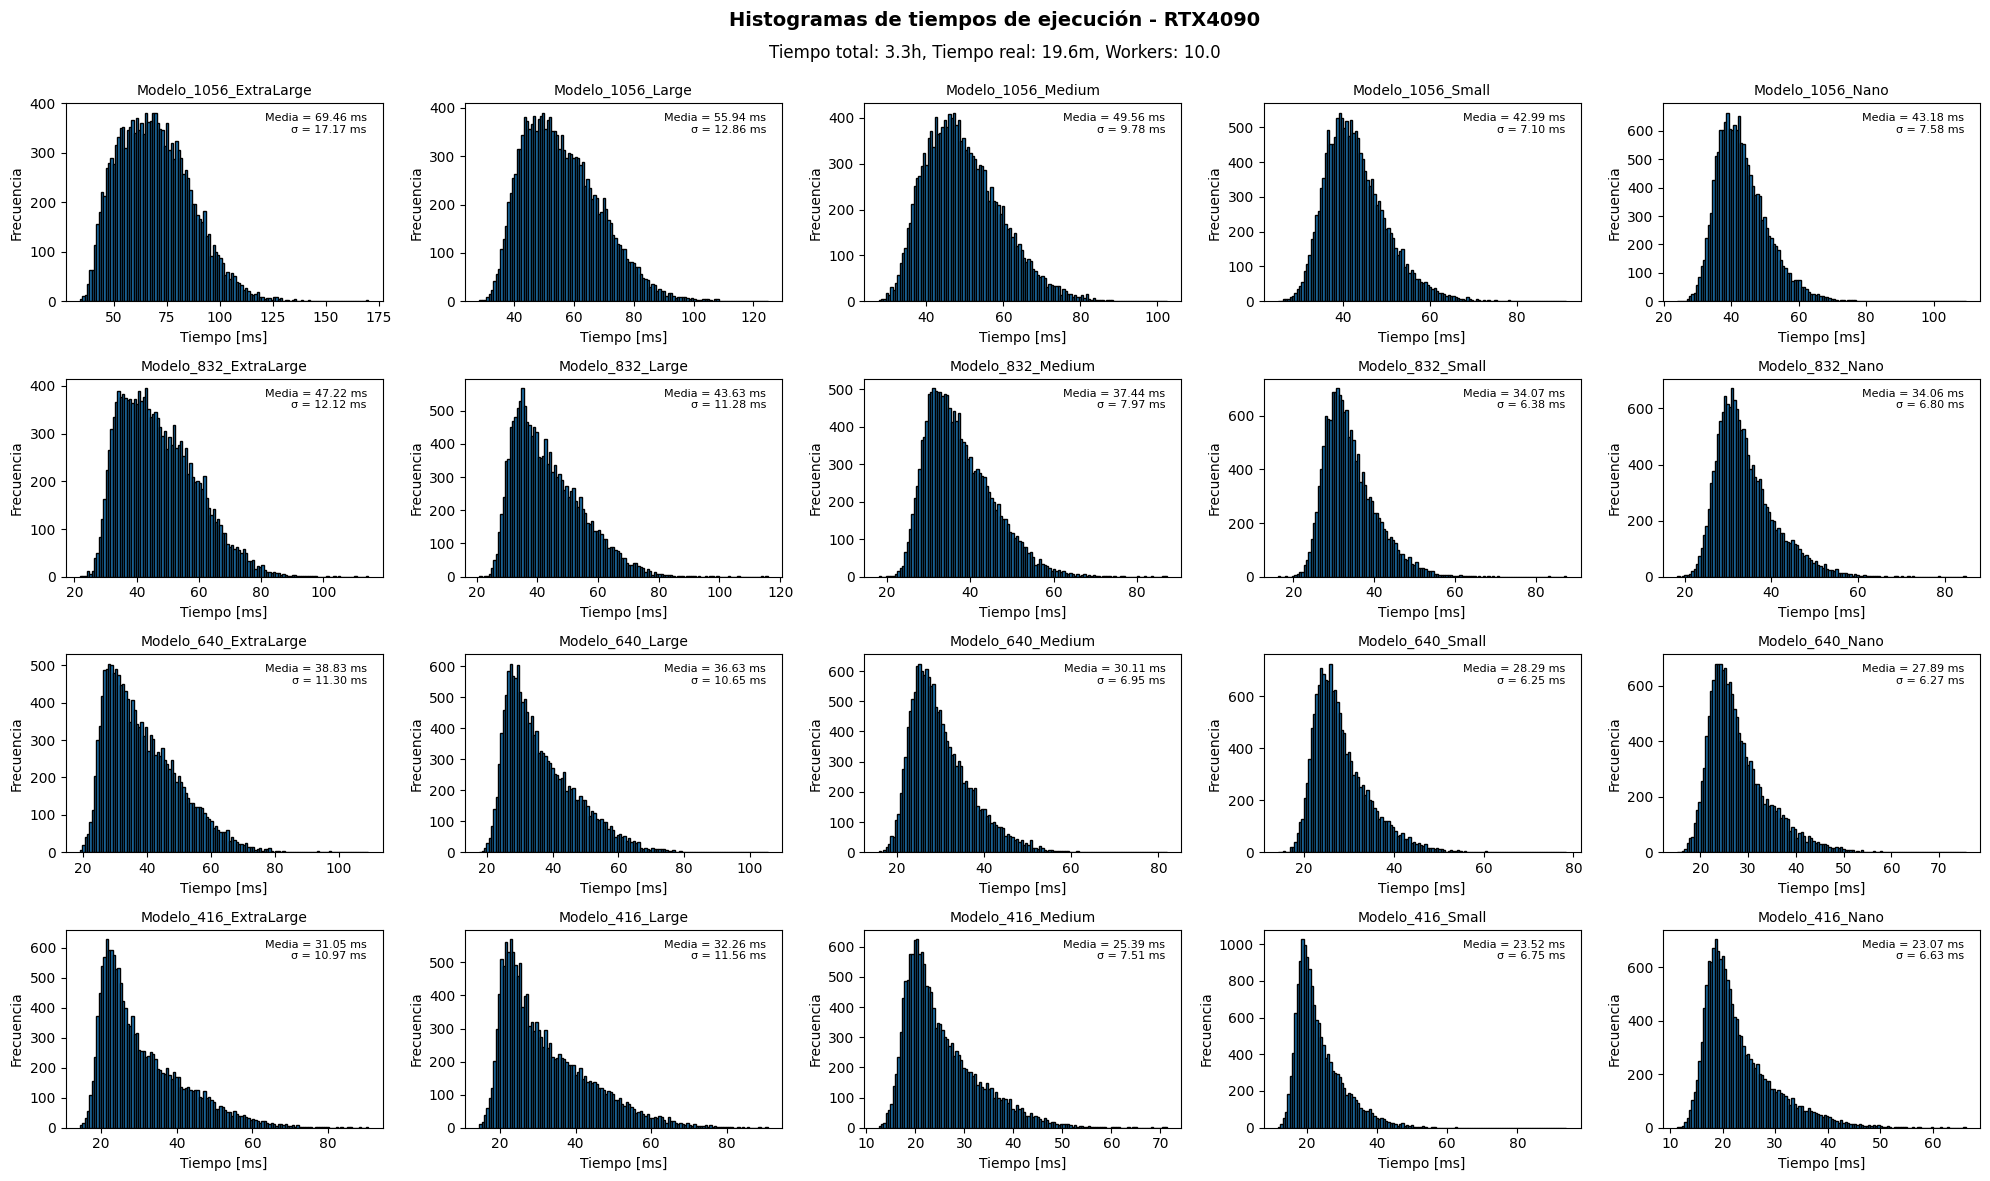

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion:



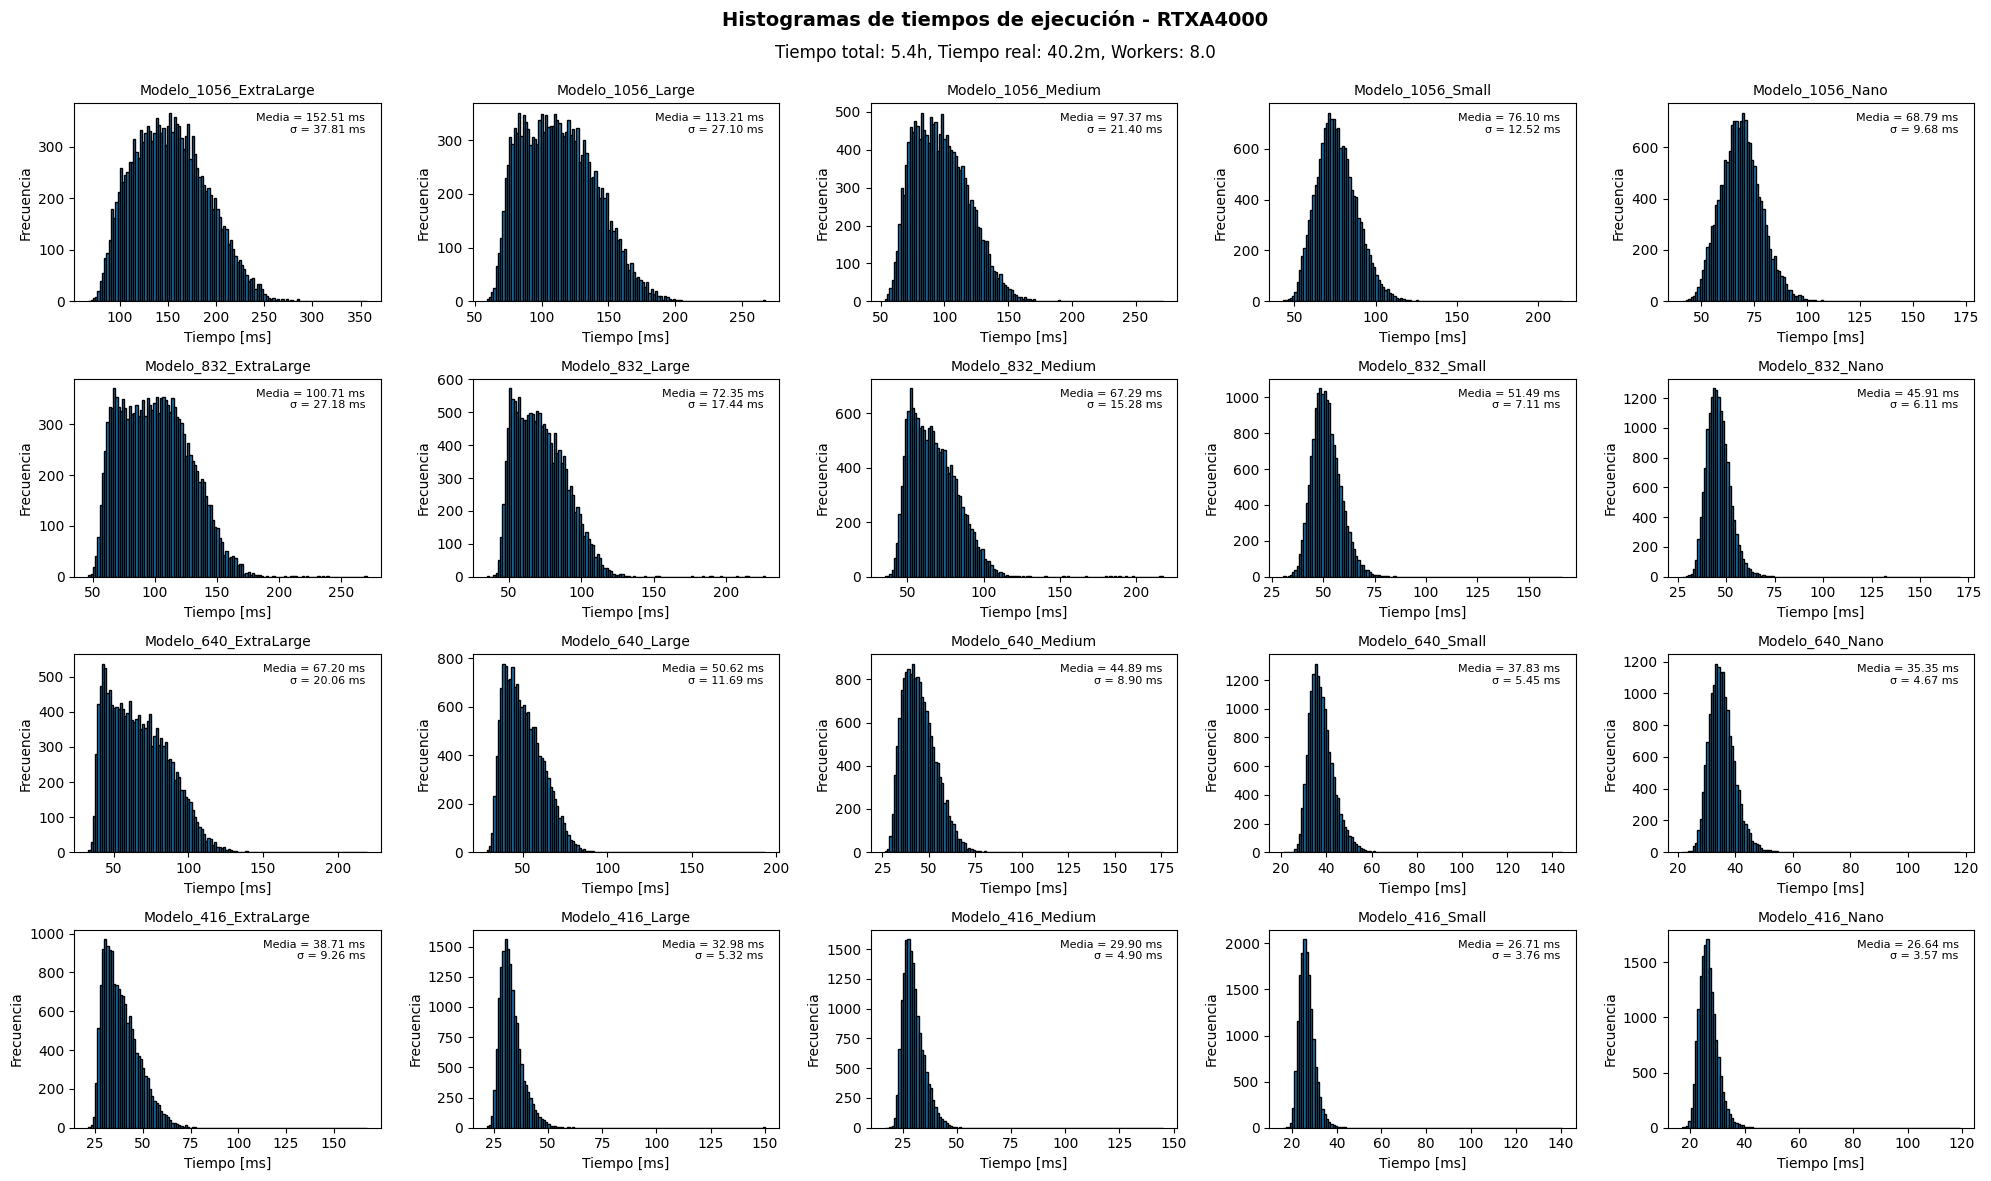

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion:



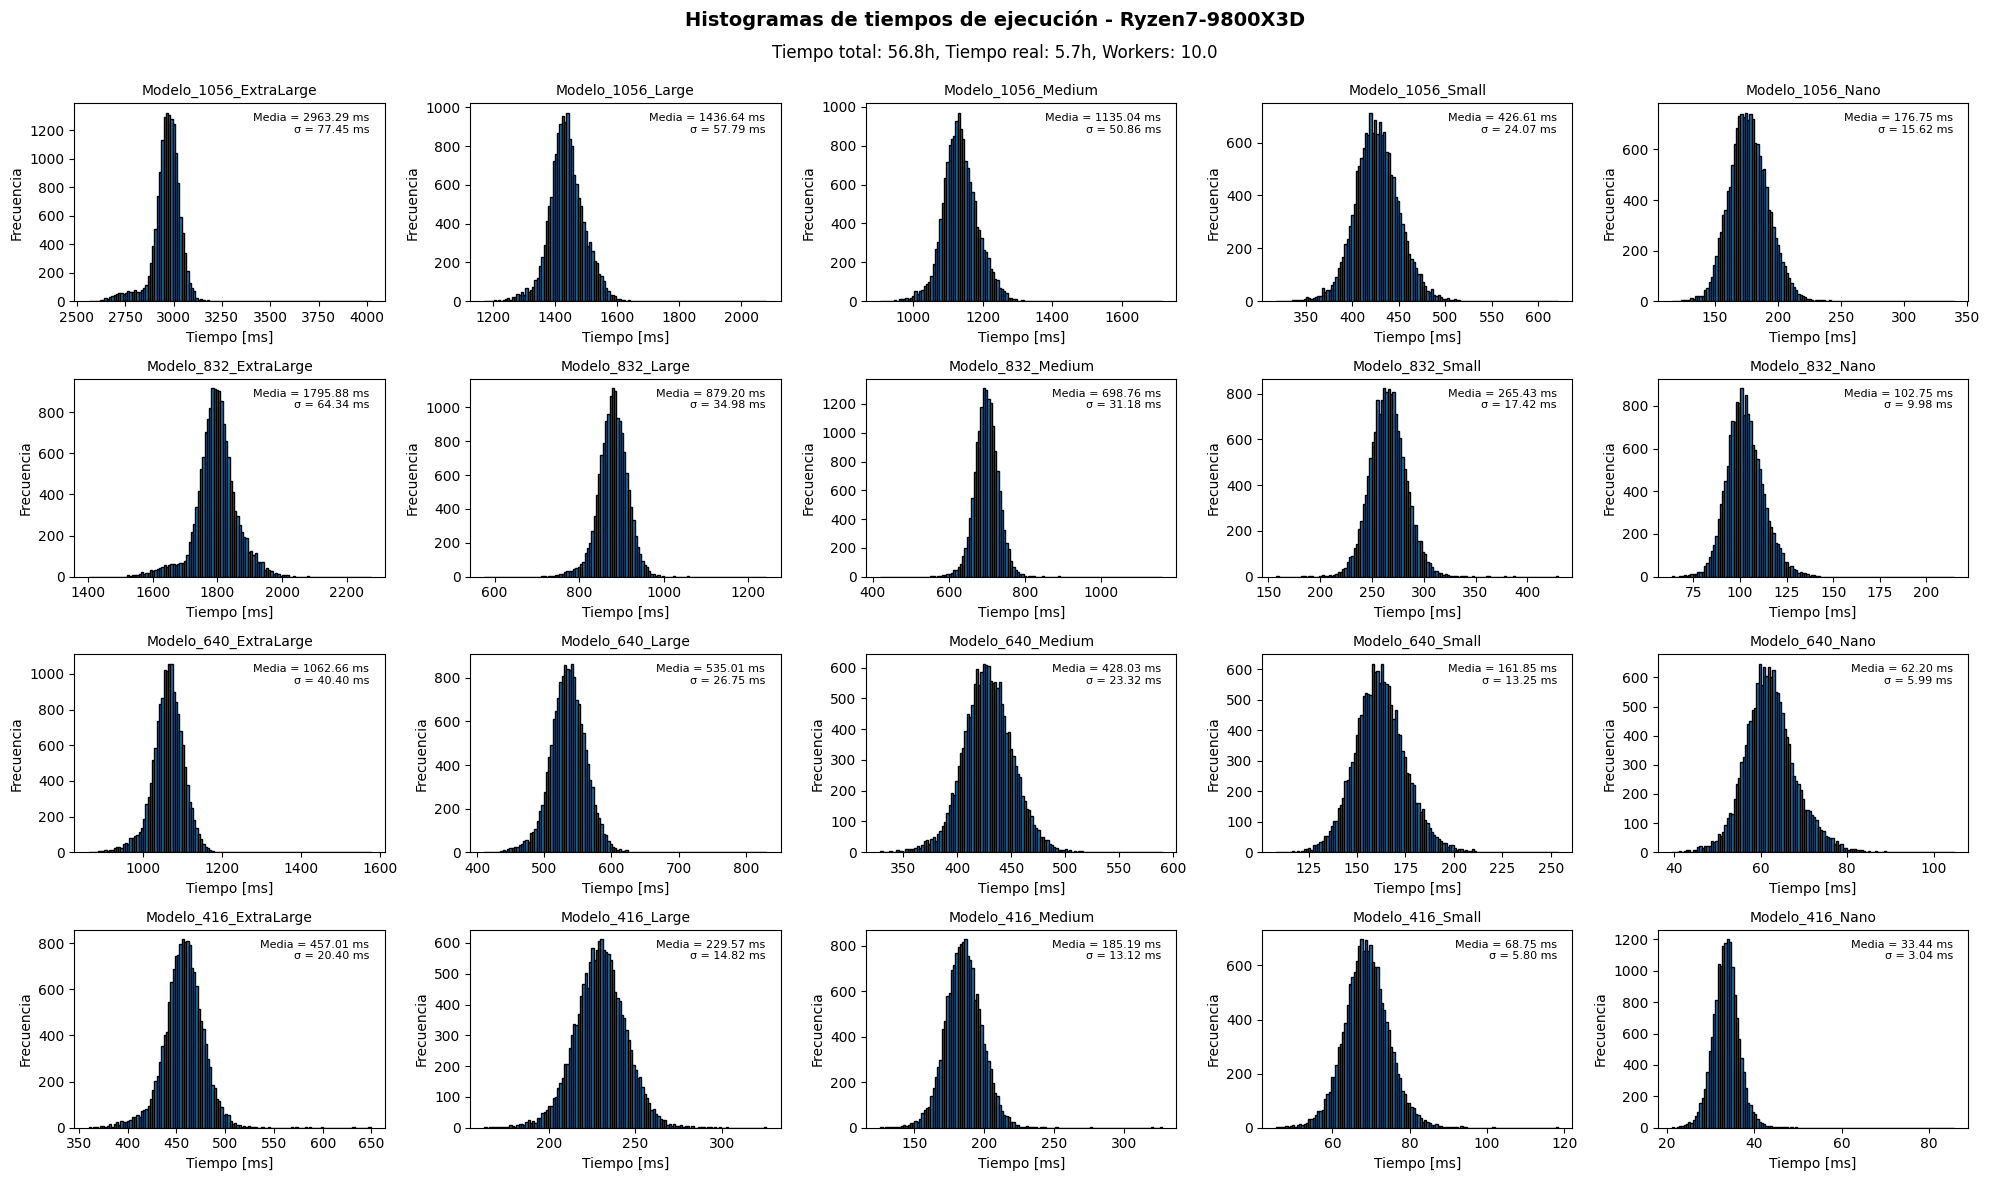

In [2]:
# ---------------- Variables -------------------------------------------------------------------------------
type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]                                             # Lista con los tipos de modelos usados
size_order = [1056, 832, 640, 416]                                                                          # Lista con los tamaños de los modelos usados                      
Total_Registros = 0                                                                                         # Variable que contiene el total de registros procesados           

Dispositivos = {}                                                                                           # Diccionario que contiene los resultados de los diferentes dispositivos
Resultados_Modelos = {}                                                                                     # Diccionario que contiene los resultados de los diferentes modelos promediando por los dispositivos ejecutados

# ---------------- Extraccion de resultados por dispositivo ------------------------------------------------

Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Clasificacion"))                   # Ruta de los archivos de resultados de clasificacion
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]   # Lista de archivos de resultados de clasificacion
Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))                                                # Ruta de salida de los archivos generados

for file in Ruta_Archivos:                                                  # Iterar sobre cada archivo de resultados de clasificacion
    Resultados_Dispositivo = Clasification_Results(file)                    # Obtener los resultados de clasificacion para el dispositivo actual

    for dispositivo, modelos in Resultados_Dispositivo.items():             # Agregar el numero de cores y tiempo total de ejecucion para cada dispositivo
        Resultados_Dispositivo[dispositivo].update({
            'Cores':float(file.split("_workers")[0].split("_")[-1]),
            'Total time [ms]':0})

        for modelo, resultados in modelos.items():                                          # Buscar en cada modelo los tiempos de ejecucion
            if (modelo != 'Cores' and modelo != 'Total time [ms]'):
                for value in resultados['Speed']:                       
                    Resultados_Dispositivo[dispositivo]['Total time [ms]'] += value         # Sumar los tiempos de ejecucion de cada modelo
                
    Dispositivos.update(Resultados_Dispositivo)                                             # Actualizar el diccionario de dispositivos con los resultados de clasificacion

# ---------------- Concatenando resultados por modelo ------------------------------------------------------

for modelo, Resultados in next(iter(Dispositivos.values())).items():        # Obtener todos los modelos del primer dispositivo, y inicializar sus listas de resultados
    if (modelo != 'Cores' and modelo != 'Total time [ms]'):
        Resultados_Modelos[modelo] = {
            'Embarcacion': [],
            'Falso_Negativo':[],
            'Falso_Positivo':[],
            'No_Embarcacion':[],
            'Probs':[]
        }
        # Sumar el total de registros procesados (Util para normalizar resultados) 
        Total_Registros=Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']

for _, Modelos in Dispositivos.items():                                     # Iterar sobre cada dispositivo y sus modelos    
    for modelo, resultados in Modelos.items():                              # Iterar sobre cada modelo y sus resultados
        if (modelo != 'Cores' and modelo != 'Total time [ms]'):             # Ignorar las entradas que no son modelos
        
            for resultado, Valor in resultados.items():                     # Iterar sobre cada resultado y su valor
                if(resultado == 'Probs'):                                   # Si el resultado es una lista de probabilidades, agregar cada probabilidad a la lista correspondiente
                    for prob in Valor:
                        Resultados_Modelos[modelo][resultado].append(prob)
                elif(resultado != 'Speed'):                                 # Descarta el resultado de la velocidad de ejecucion, y agrega los demas resultados (Detecciones de embarcaciones, falsos positivos, etc)
                    Resultados_Modelos[modelo][resultado].append(Valor)     
            
# ---------------- Analisis de resultados por modelo -------------------------------------------------------
data = {}                                                                                           # Diccionario auxiliar

for modelo, resultados in Resultados_Modelos.items():                                               # Iterar sobre cada modelo y sus resultados
    match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                               # Extraer el tamaño y tipo del modelo usando expresiones regulares
    if match:                                                                                       # Si se encontró una coincidencia, extraer el tamaño y tipo
        size = int(match.group(1))
        model_type = match.group(2)
    else:                                                                                           # Si no se encontró una coincidencia, asignar valores por defecto
        size = "Desconocido"
        model_type = "Desconocido"

    col_label = (size, model_type)                                                                  # Crear una etiqueta de columna como una tupla (tamaño, tipo)                

    metrics = {                                                                                     # Calcular las métricas de interés y almacenarlas en un diccionario
        "Embarcación":          (stats.mean(resultados["Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Embarcacion"]) * 100 / Total_Registros),

        "No Embarcación":       (stats.mean(resultados["No_Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["No_Embarcacion"]) * 100 / Total_Registros),

        "Falso Negativo":       (stats.mean(resultados["Falso_Negativo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Negativo"]) * 100 / Total_Registros),

        "Falso Positivo":       (stats.mean(resultados["Falso_Positivo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Positivo"]) * 100 / Total_Registros),

        "Probabilidad media":   (stats.mean(resultados["Probs"]) if resultados["Probs"] else None,
                                stats.stdev(resultados["Probs"]) if len(resultados["Probs"]) > 1 else None),
    }

    for metric, (mean, std) in metrics.items():             # Iterar sobre cada métrica y su valor (media y desviación estándar)
        if metric not in data:                              # Si la métrica no está en el diccionario auxiliar, inicializarla
            data[metric] = {}
        data[metric][col_label] = f"{mean:.2f}±{std:.2f}"   # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame(data).T                                                           # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden                             

# Mostrar tabla
print("\nMatriz de confusión promedio (promediada en todos los dispositivos):\n")
print(df)

# ---------------- Analisis de resultados por dispositivo - Tiempo de ejecucion ----------------------------
data = {}                                                                                           # Diccionario auxiliar

for dispositivo, modelos in Dispositivos.items():                                                   # Iterar sobre cada dispositivo y sus resultados
    data[dispositivo] = {}                                                                          # Inicializar el diccionario para el dispositivo actual
    
    for modelo, resultados in modelos.items():                                                      # Iterar sobre cada modelo y sus resultados
        if modelo not in ('Cores', 'Total time [ms]'):                                              # Ignorar las entradas que no son modelos
            
            match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                       # Extraer el tamaño y tipo del modelo usando expresiones regulares
            if match:                                                                               # Si se encontró una coincidencia, extraer el tamaño y tipo
                size = int(match.group(1))
                model_type = match.group(2)
            else:                                                                                   # Si no se encontró una coincidencia, asignar valores por defecto
                size = "Desconocido"
                model_type = "Desconocido"

            col_label = (size, model_type)                                                          # Crear una etiqueta de columna como una tupla (tamaño, tipo)

            mean = stats.mean(resultados["Speed"])                                                  # Calcular la media de los tiempos de ejecución 
            std = stats.stdev(resultados["Speed"]) if len(resultados["Speed"]) > 1 else 0           # Calcular la desviación estándar de los tiempos de ejecución (0 si solo hay un valor)    

            data[dispositivo][col_label] = f"{mean:.2f}±{std:.2f}"                                  # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame.from_dict(data, orient="index")                                   # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden   

# Mostrar tabla
print("\nTiempos de ejecución promedio por dispositivo (ms):\n")
print(df)

# ---------------- Imprimir Distribuciones estadisticas ----------------------------------------------------

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida, "Ejecucion_Clasificacion_Dispositivo.pdf"))) as pdf:   # Crear un archivo PDF para guardar las figuras
    for dispositivo, modelos in Dispositivos.items():                                                           # Cada dispositivo representa una figura/pagina nueva
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion:\n")

        # --- Extraer Cores y tiempo total del mismo diccionario ---
        cores = modelos.get("Cores", 1)
        total_ms = modelos.get("Total time [ms]", 0)

        # --- Ordenar modelos según resolución y tipo ---
        modelos_ordenados = []
        for size in size_order:
            for tipo in type_order:
                for modelo in modelos.keys():
                    if re.search(fr"_{size}_{tipo}$", modelo):
                        modelos_ordenados.append(modelo)

        # Crear figura
        fig, axs = plt.subplots(4, 5, figsize=(20, 12))
        axs = axs.flatten()

        for i, modelo in enumerate(modelos_ordenados):
            if i >= len(axs):  # Limitar a 20 plots por dispositivo
                break

            resultados = modelos[modelo]    
            if "Speed" not in resultados:
                continue

            datos = resultados["Speed"]
            if len(datos) == 0:
                continue

            media = stats.mean(datos)
            sigma = stats.stdev(datos) if len(datos) > 1 else 0

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        # Desactivar los ejes vacíos
        for j in range(i + 1, len(axs)):
            axs[j].axis("off")

        # --- Calcular tiempos totales y reales ---
        tiempo_total = total_ms / (1000 * 60 * 60)
        tiempo_total_str = f"{round(tiempo_total, 1)}h"

        tiempo_real = total_ms / (1000 * 60 * 60 * cores)
        tiempo_real_str = f"{round(tiempo_real * 60, 1)}m" if tiempo_real < 1 else f"{round(tiempo_real, 1)}h"

        # --- Título general ---
        plt.suptitle(
            f"Histogramas de tiempos de ejecución - {dispositivo}",
            fontsize=14, fontweight="bold"
        )
        fig.text(
            0.5, 0.94,
            f"Tiempo total: {tiempo_total_str}, Tiempo real: {tiempo_real_str}, Workers: {cores}",
            ha="center", fontsize=12
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)


# Evaluacion de los resultados de los modelos de deteccion de imagenes

El objetivo del siguiente segmento de codigo es procesar los resultados obtenidos de los modelos de deteccion de imagenes en diferentes dispositivos (CPU, GPU) y generar estadisticas y graficas de los resultados obtenidos.


Matriz de confusión promedio (promediada en todos los dispositivos):

Resolución                1056                                      \
Tipo                ExtraLarge       Large      Medium       Small   
Embarcación         13.40±0.00  13.29±0.00  13.53±0.00  13.50±0.01   
No Embarcación      79.04±0.00  79.05±0.00  79.00±0.00  78.94±0.00   
Falso Negativo       0.10±0.00   0.14±0.00   0.13±0.00   0.09±0.00   
Falso Positivo       7.42±0.01   7.44±0.00   7.65±0.00   7.55±0.01   
Probabilidad media   0.94±0.14   0.94±0.14   0.94±0.14   0.95±0.13   
IoU media            0.52±0.37   0.52±0.37   0.52±0.37   0.52±0.37   

Resolución                            832                           \
Tipo                      Nano  ExtraLarge       Large      Medium   
Embarcación         13.14±0.00  13.21±0.00  13.02±0.00  13.27±0.00   
No Embarcación      78.88±0.01  78.99±0.00  78.97±0.00  79.05±0.00   
Falso Negativo       0.12±0.00   0.11±0.00   0.12±0.00   0.14±0.00   
Falso Positivo    

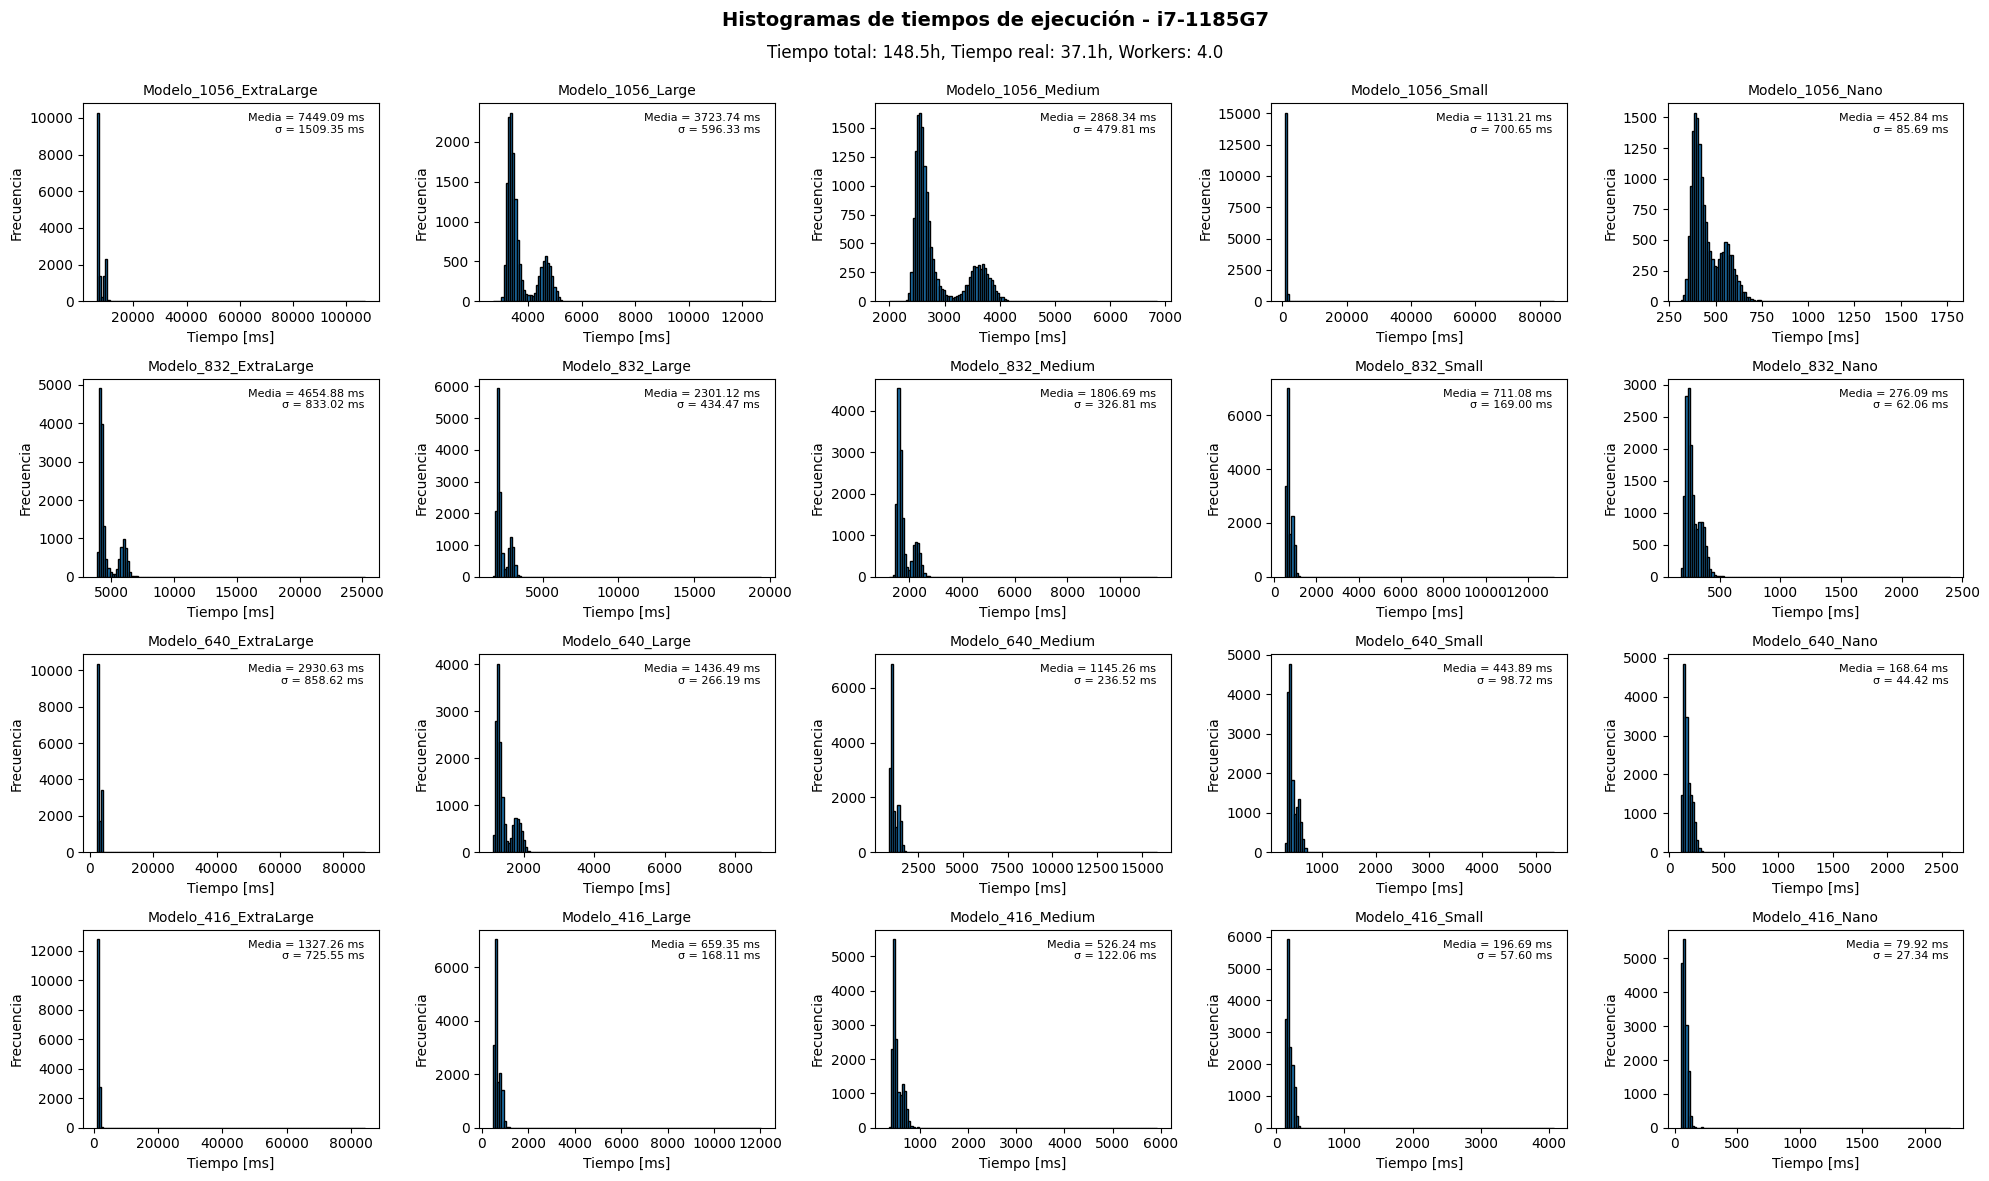

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion:



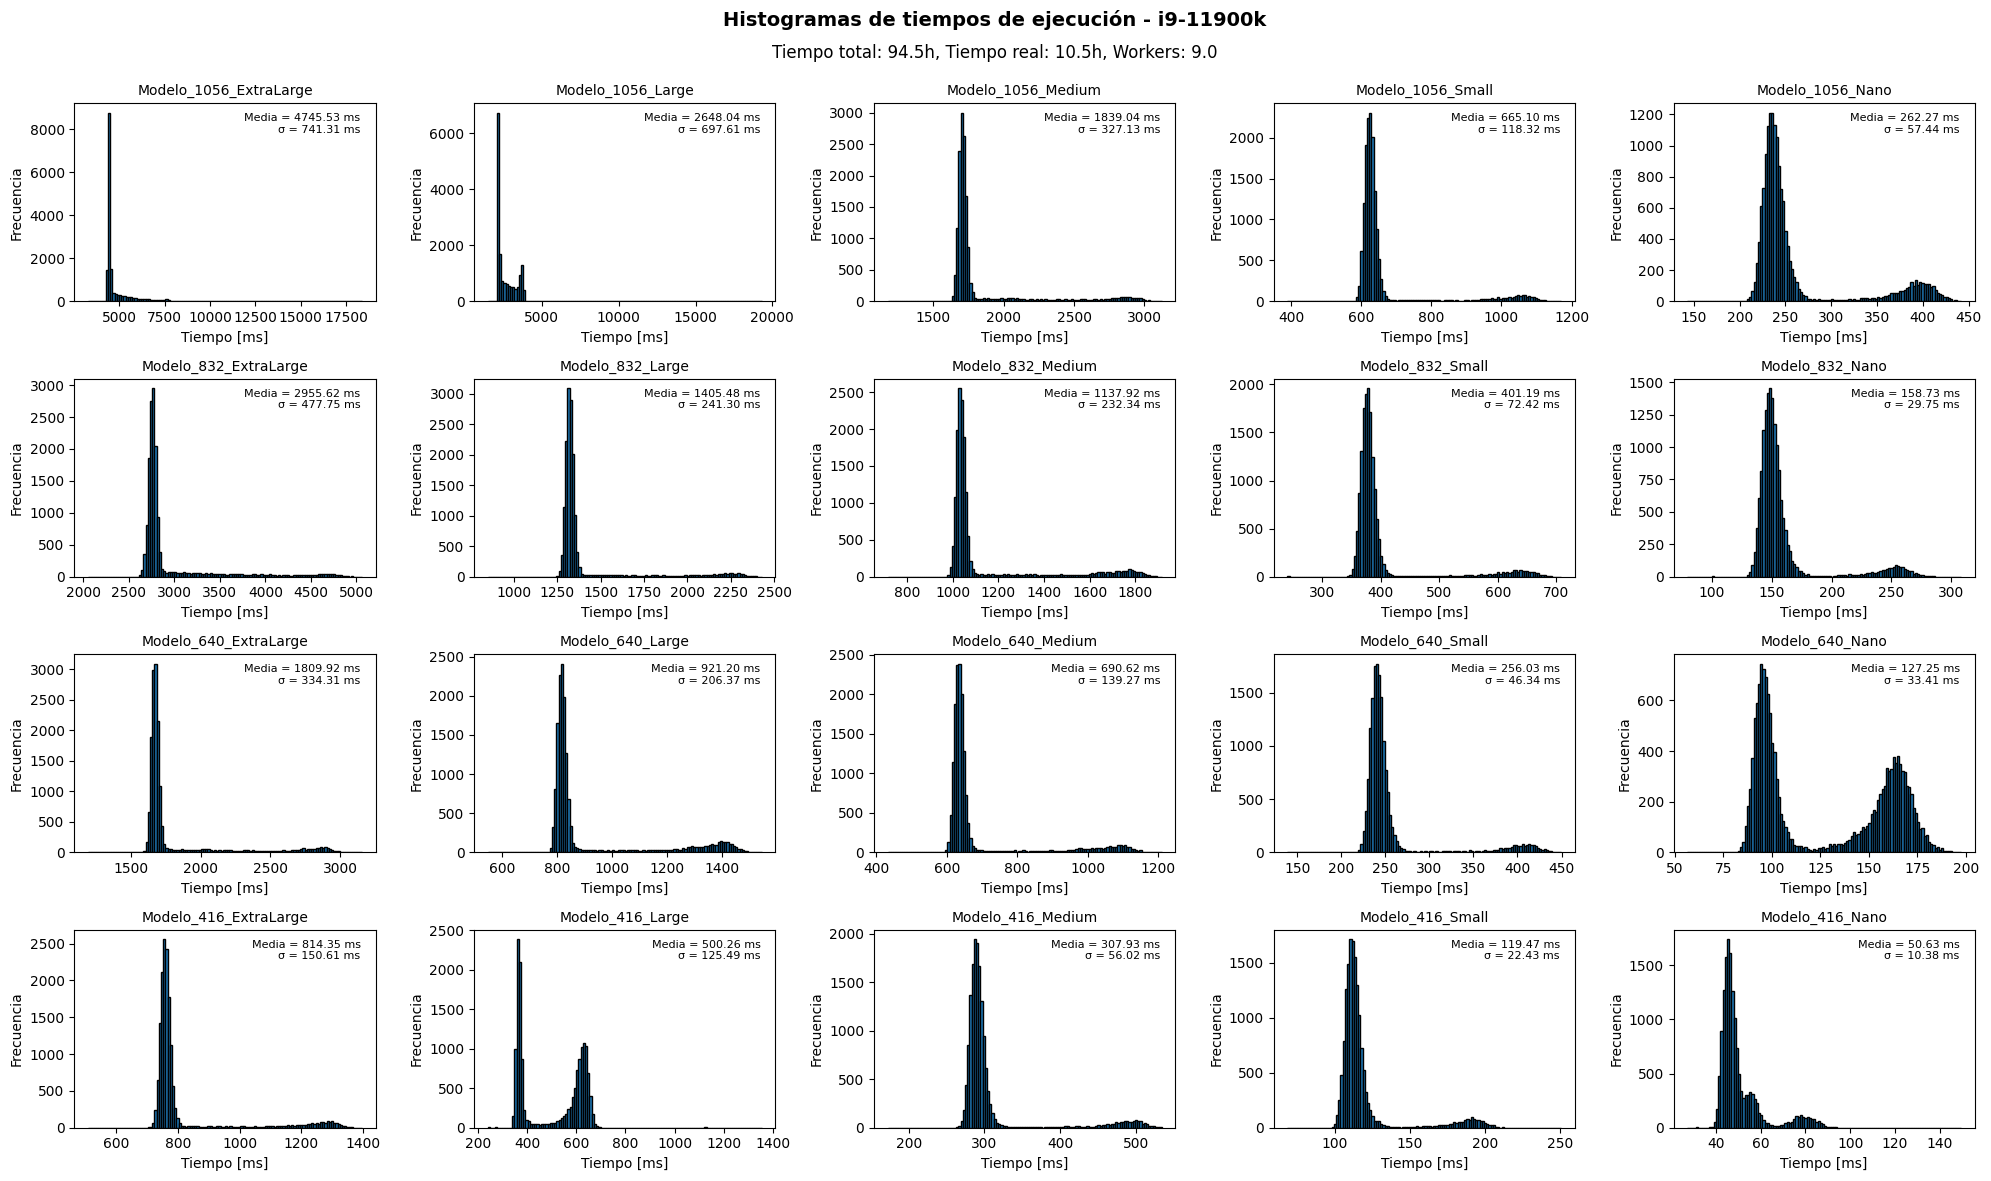

Para el dispositivo RaspberryPi5, se tienen los siguientes tiempos de ejecucion:



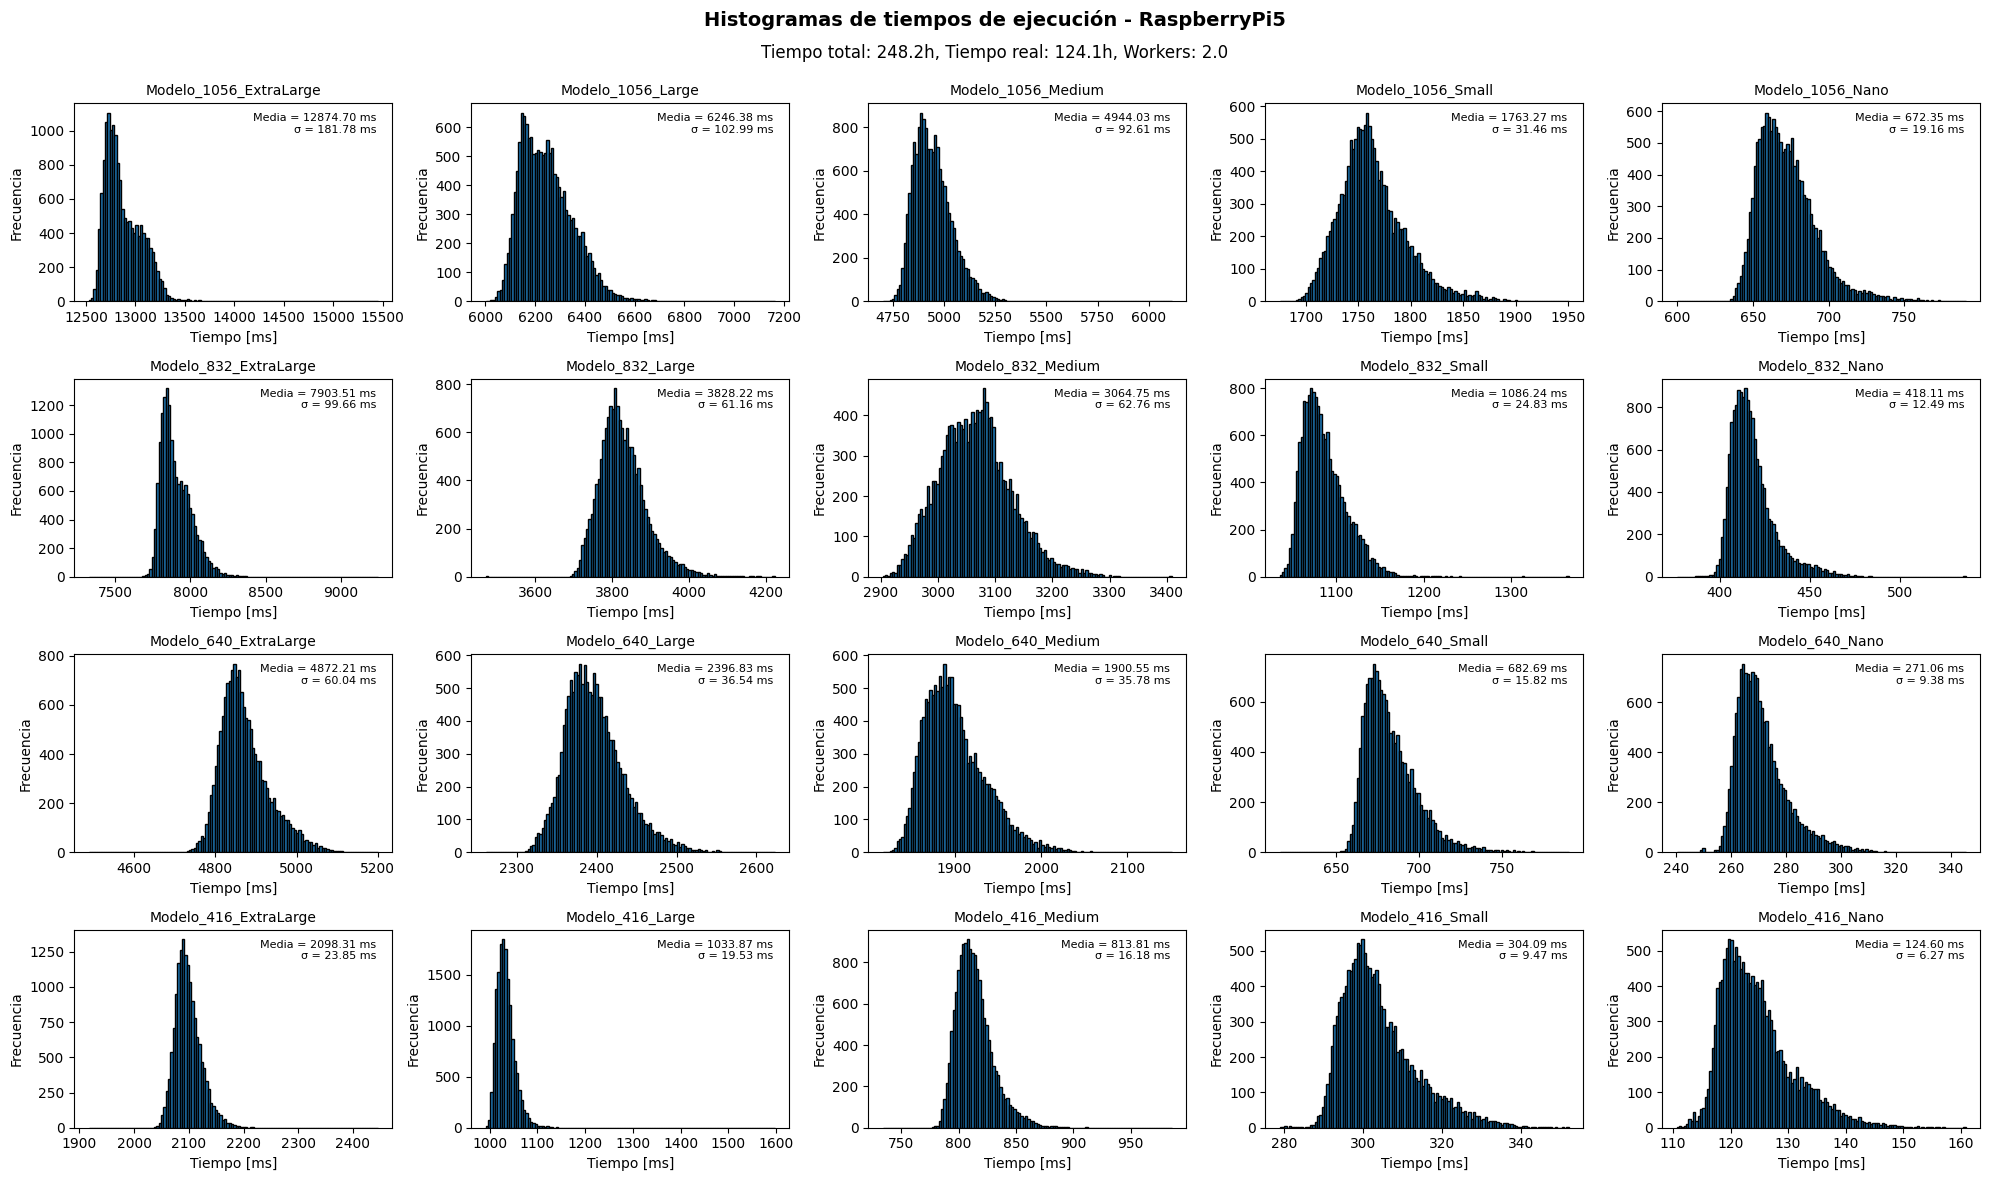

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion:



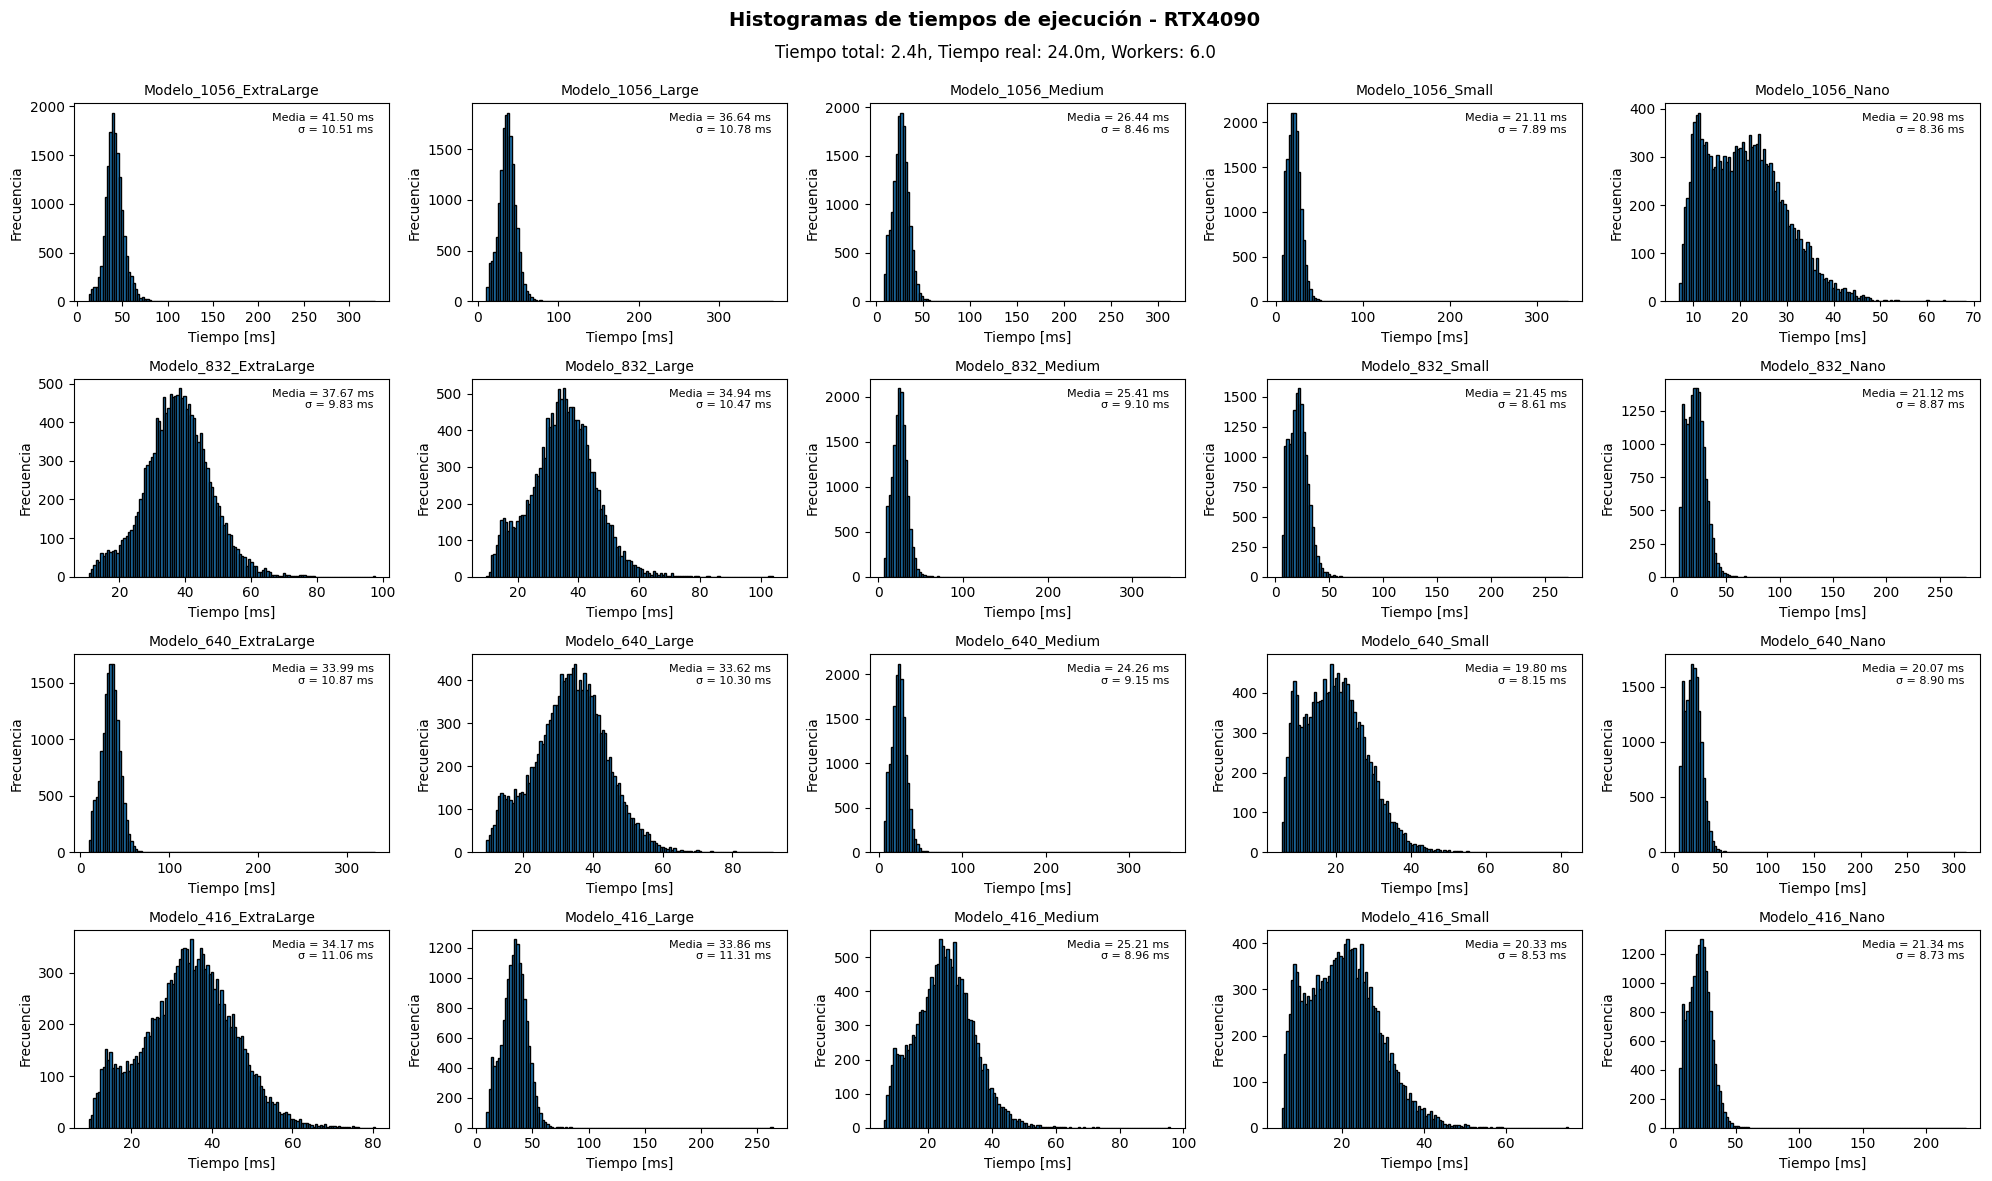

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion:



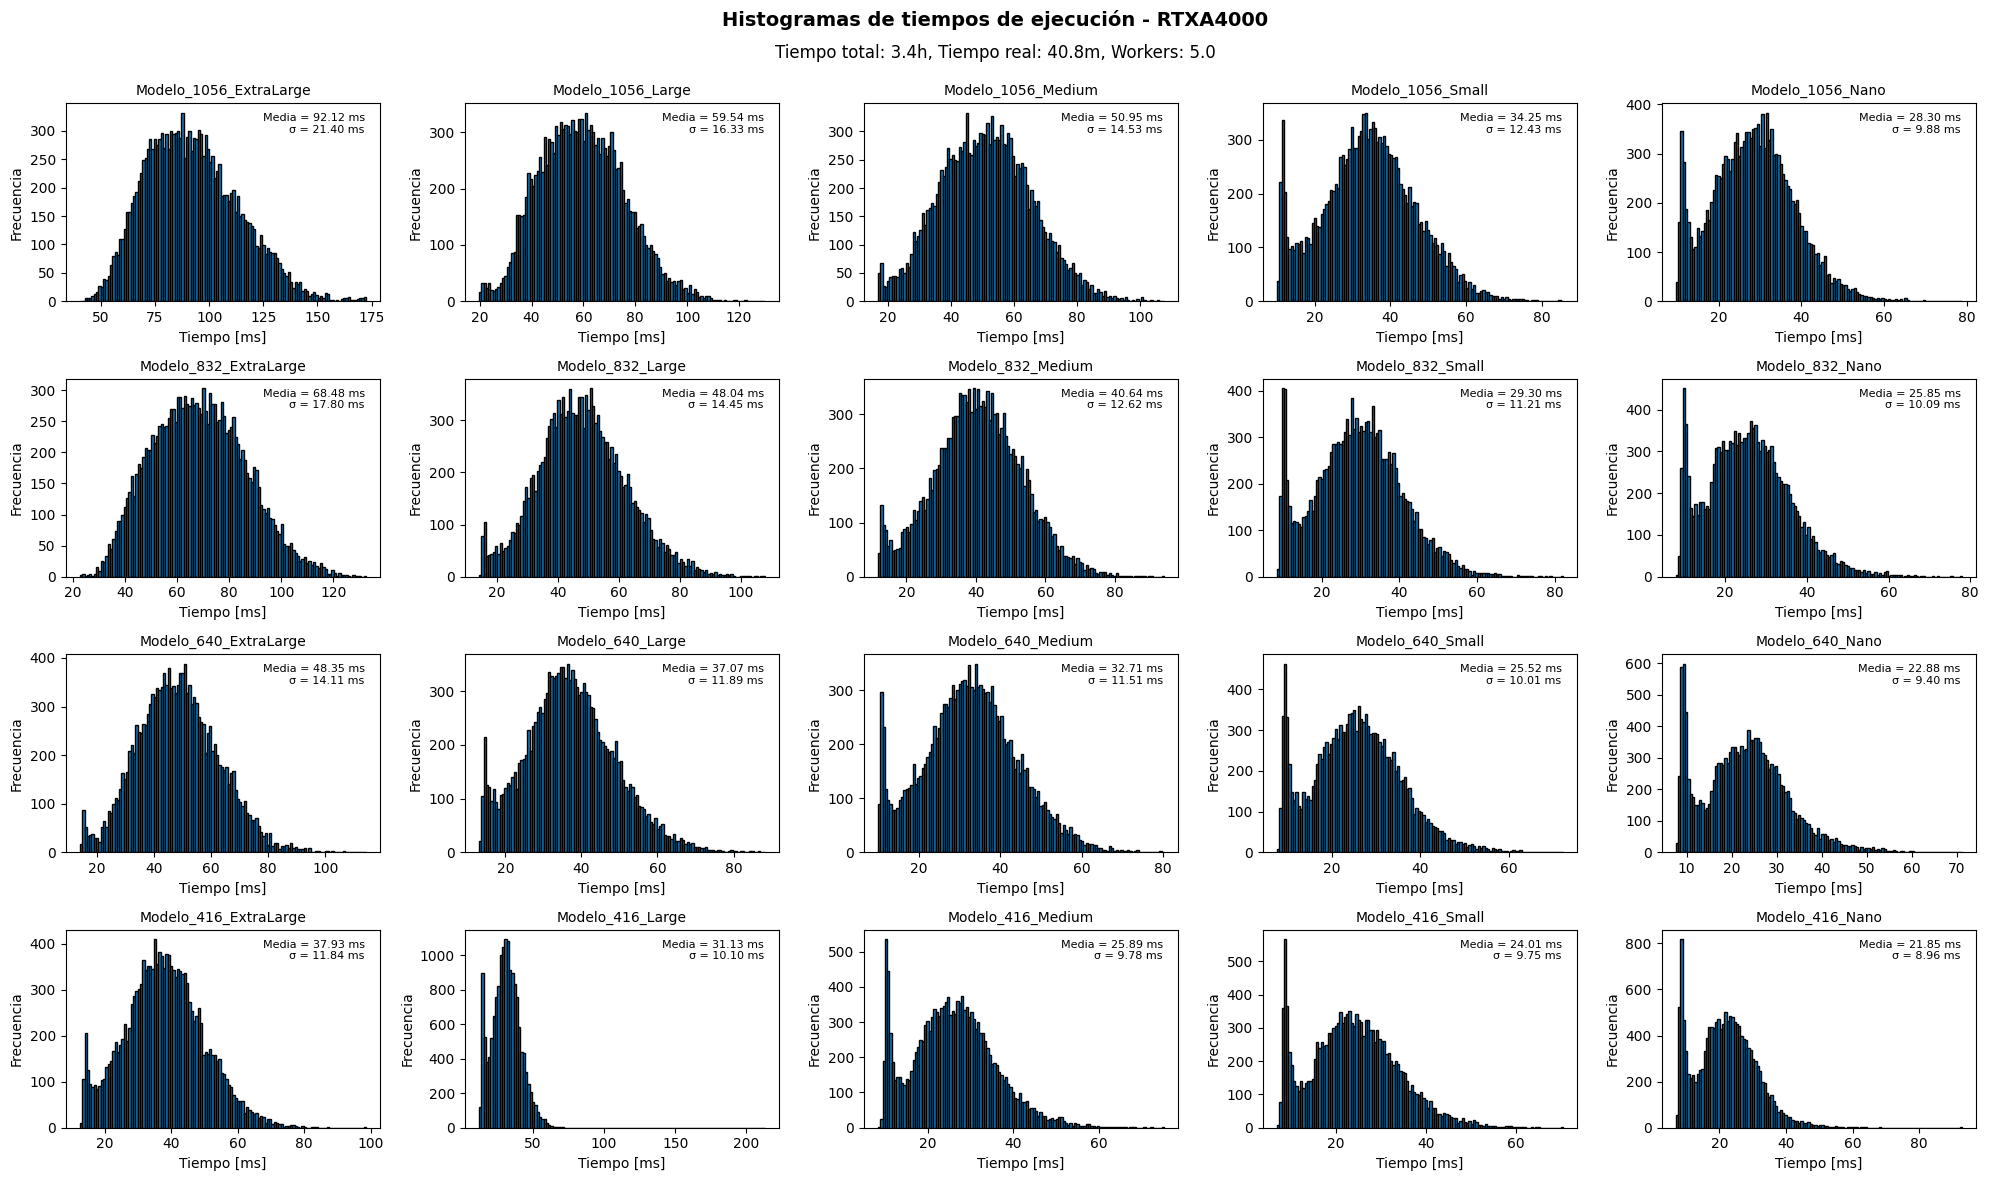

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion:



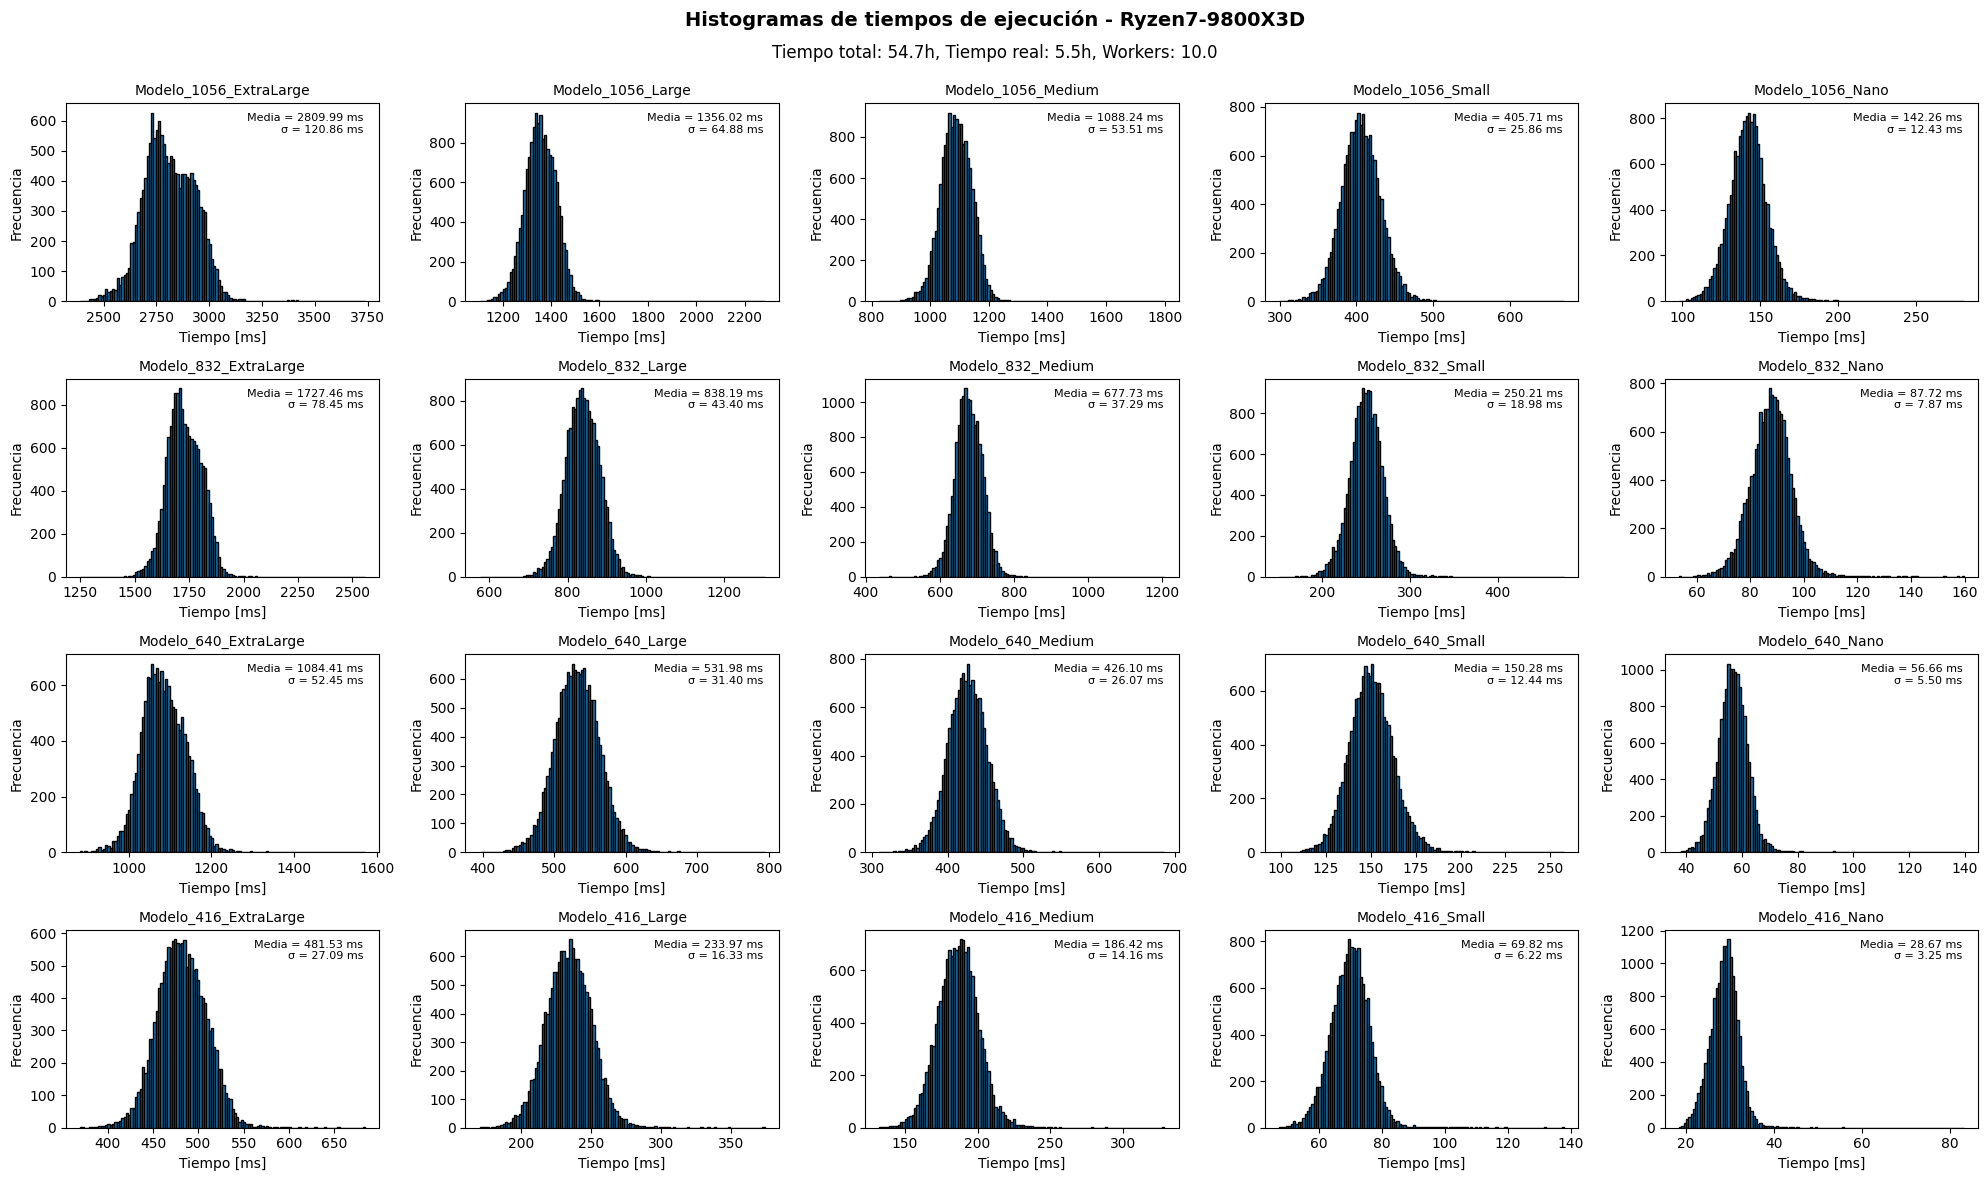

In [3]:
# ---------------- Variables -------------------------------------------------------------------------------
type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]                                             # Lista con los tipos de modelos usados
size_order = [1056, 832, 640, 416]                                                                          # Lista con los tamaños de los modelos usados                      
Total_Registros = 0                                                                                         # Variable que contiene el total de registros procesados           

Dispositivos = {}                                                                                           # Diccionario que contiene los resultados de los diferentes dispositivos
Resultados_Modelos = {}                                                                                     # Diccionario que contiene los resultados de los diferentes modelos promediando por los dispositivos ejecutados

# ---------------- Extraccion de resultados por dispositivo ------------------------------------------------

Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Segmentacion"))                   # Ruta de los archivos de resultados de clasificacion
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]   # Lista de archivos de resultados de clasificacion
Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))                                                # Ruta de salida de los archivos generados

for file in Ruta_Archivos:                                                  # Iterar sobre cada archivo de resultados de clasificacion
    Resultados_Dispositivo = Segmentation_Results(file)                    # Obtener los resultados de clasificacion para el dispositivo actual

    for dispositivo, modelos in Resultados_Dispositivo.items():             # Agregar el numero de cores y tiempo total de ejecucion para cada dispositivo
        Resultados_Dispositivo[dispositivo].update({
            'Cores':float(file.split("_workers")[0].split("_")[-1]),
            'Total time [ms]':0})

        for modelo, resultados in modelos.items():                                          # Buscar en cada modelo los tiempos de ejecucion
            if (modelo != 'Cores' and modelo != 'Total time [ms]'):
                for value in resultados['Speed']:                       
                    Resultados_Dispositivo[dispositivo]['Total time [ms]'] += value         # Sumar los tiempos de ejecucion de cada modelo
                
    Dispositivos.update(Resultados_Dispositivo)                                             # Actualizar el diccionario de dispositivos con los resultados de clasificacion

# ---------------- Concatenando resultados por modelo ------------------------------------------------------

for modelo, Resultados in next(iter(Dispositivos.values())).items():        # Obtener todos los modelos del primer dispositivo, y inicializar sus listas de resultados
    if (modelo != 'Cores' and modelo != 'Total time [ms]'):
        Resultados_Modelos[modelo] = {
        'Embarcacion': [],
        'Falso_Negativo':[],
        'Falso_Positivo':[],
        'No_Embarcacion':[],
        'Probs':[],
        'IoU':[]
        }
        # Sumar el total de registros procesados (Util para normalizar resultados) 
        Total_Registros=Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']



for _, Modelos in Dispositivos.items():                                     # Iterar sobre cada dispositivo y sus modelos    
    for modelo, resultados in Modelos.items():                              # Iterar sobre cada modelo y sus resultados
        if (modelo != 'Cores' and modelo != 'Total time [ms]'):             # Ignorar las entradas que no son modelos
        
            for resultado, Valor in resultados.items():                     # Iterar sobre cada resultado y su valor
                if(resultado == 'Probs'):                                   # Si el resultado es una lista de probabilidades, agregar cada probabilidad a la lista correspondiente
                    for prob in Valor:
                        Resultados_Modelos[modelo][resultado].append(prob)
                elif(resultado == 'IoU'):                                   # Si el resultado es una lista de Intersection over Union, agregar cada valor a la lista correspondiente
                    for IntersectionOverUnion in Valor:
                        Resultados_Modelos[modelo][resultado].append(IntersectionOverUnion)                         
                elif(resultado != 'Speed'):                                 # Descarta el resultado de la velocidad de ejecucion, y agrega los demas resultados (Detecciones de embarcaciones, falsos positivos, etc)
                    Resultados_Modelos[modelo][resultado].append(Valor)     

# ---------------- Analisis de resultados por modelo -------------------------------------------------------
data = {}                                                                                           # Diccionario auxiliar

for modelo, resultados in Resultados_Modelos.items():                                               # Iterar sobre cada modelo y sus resultados
    match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                               # Extraer el tamaño y tipo del modelo usando expresiones regulares
    if match:                                                                                       # Si se encontró una coincidencia, extraer el tamaño y tipo
        size = int(match.group(1))
        model_type = match.group(2)
    else:                                                                                           # Si no se encontró una coincidencia, asignar valores por defecto
        size = "Desconocido"
        model_type = "Desconocido"

    col_label = (size, model_type)                                                                  # Crear una etiqueta de columna como una tupla (tamaño, tipo)                

    metrics = {                                                                                     # Calcular las métricas de interés y almacenarlas en un diccionario
        "Embarcación":          (stats.mean(resultados["Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Embarcacion"]) * 100 / Total_Registros),

        "No Embarcación":       (stats.mean(resultados["No_Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["No_Embarcacion"]) * 100 / Total_Registros),

        "Falso Negativo":       (stats.mean(resultados["Falso_Negativo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Negativo"]) * 100 / Total_Registros),

        "Falso Positivo":       (stats.mean(resultados["Falso_Positivo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Positivo"]) * 100 / Total_Registros),

        "Probabilidad media":   (stats.mean(resultados["Probs"]) if resultados["Probs"] else None,
                                stats.stdev(resultados["Probs"]) if len(resultados["Probs"]) > 1 else None),

        "IoU media":   (stats.mean(resultados["IoU"]) if resultados["IoU"] else None,
                        stats.stdev(resultados["IoU"]) if len(resultados["IoU"]) > 1 else None),
    }

    for metric, (mean, std) in metrics.items():             # Iterar sobre cada métrica y su valor (media y desviación estándar)
        if metric not in data:                              # Si la métrica no está en el diccionario auxiliar, inicializarla
            data[metric] = {}
        data[metric][col_label] = f"{mean:.2f}±{std:.2f}"   # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame(data).T                                                           # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden                             

# Mostrar tabla
print("\nMatriz de confusión promedio (promediada en todos los dispositivos):\n")
print(df)

# ---------------- Analisis de resultados por dispositivo - Tiempo de ejecucion ----------------------------
data = {}                                                                                           # Diccionario auxiliar

for dispositivo, modelos in Dispositivos.items():                                                   # Iterar sobre cada dispositivo y sus resultados
    data[dispositivo] = {}                                                                          # Inicializar el diccionario para el dispositivo actual
    
    for modelo, resultados in modelos.items():                                                      # Iterar sobre cada modelo y sus resultados
        if modelo not in ('Cores', 'Total time [ms]'):                                              # Ignorar las entradas que no son modelos
            
            match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                       # Extraer el tamaño y tipo del modelo usando expresiones regulares
            if match:                                                                               # Si se encontró una coincidencia, extraer el tamaño y tipo
                size = int(match.group(1))
                model_type = match.group(2)
            else:                                                                                   # Si no se encontró una coincidencia, asignar valores por defecto
                size = "Desconocido"
                model_type = "Desconocido"

            col_label = (size, model_type)                                                          # Crear una etiqueta de columna como una tupla (tamaño, tipo)

            mean = stats.mean(resultados["Speed"])                                                  # Calcular la media de los tiempos de ejecución 
            std = stats.stdev(resultados["Speed"]) if len(resultados["Speed"]) > 1 else 0           # Calcular la desviación estándar de los tiempos de ejecución (0 si solo hay un valor)    

            data[dispositivo][col_label] = f"{mean:.2f}±{std:.2f}"                                  # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame.from_dict(data, orient="index")                                   # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden   

# Mostrar tabla
print("\nTiempos de ejecución promedio por dispositivo (ms):\n")
print(df)

# ---------------- Imprimir Distribuciones estadisticas ----------------------------------------------------

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida, "Ejecucion_Deteccion_Dispositivo.pdf"))) as pdf:       # Crear un archivo PDF para guardar las figuras
    for dispositivo, modelos in Dispositivos.items():                                                           # Cada dispositivo representa una figura/pagina nueva
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion:\n")

        # --- Extraer Cores y tiempo total del mismo diccionario ---
        cores = modelos.get("Cores", 1)
        total_ms = modelos.get("Total time [ms]", 0)

        # --- Ordenar modelos según resolución y tipo ---
        modelos_ordenados = []
        for size in size_order:
            for tipo in type_order:
                for modelo in modelos.keys():
                    if re.search(fr"_{size}_{tipo}$", modelo):
                        modelos_ordenados.append(modelo)

        # Crear figura
        fig, axs = plt.subplots(4, 5, figsize=(20, 12))
        axs = axs.flatten()

        for i, modelo in enumerate(modelos_ordenados):
            if i >= len(axs):  # Limitar a 20 plots por dispositivo
                break

            resultados = modelos[modelo]    
            if "Speed" not in resultados:
                continue

            datos = resultados["Speed"]
            if len(datos) == 0:
                continue

            media = stats.mean(datos)
            sigma = stats.stdev(datos) if len(datos) > 1 else 0

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        # Desactivar los ejes vacíos
        for j in range(i + 1, len(axs)):
            axs[j].axis("off")

        # --- Calcular tiempos totales y reales ---
        tiempo_total = total_ms / (1000 * 60 * 60)
        tiempo_total_str = f"{round(tiempo_total, 1)}h"

        tiempo_real = total_ms / (1000 * 60 * 60 * cores)
        tiempo_real_str = f"{round(tiempo_real * 60, 1)}m" if tiempo_real < 1 else f"{round(tiempo_real, 1)}h"

        # --- Título general ---
        plt.suptitle(
            f"Histogramas de tiempos de ejecución - {dispositivo}",
            fontsize=14, fontweight="bold"
        )
        fig.text(
            0.5, 0.94,
            f"Tiempo total: {tiempo_total_str}, Tiempo real: {tiempo_real_str}, Workers: {cores}",
            ha="center", fontsize=12
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)


# Evaluacion de los resultados de la base de datos

El objetivo del siguiente segmento de codigo es procesar los resultados obtenidos de la base de datos teniendo en cuenta la informacion del radar y su respectiva clasificacion de las imagenes.

La base de datos contiene un aproximado de 10966 correos diferentes
La cantidad de correos sin imágenes son: 5076, corresponde a un 46.289% de los correos

La cantidad de correos con imágenes son: 5890, corresponde a un 53.711% de los correos
Los correos con imágenes pero sin embarcaciones son: 5280, corresponde a un 48.149% de los correos
Los correos con imágenes y con embarcaciones son: 610, corresponde a un 5.563% de los correos

En total se disponen de 13718 imágenes sin embarcaciones
En total se disponen de 1877 imágenes con embarcaciones
Se obtuvieron un total de 15595 imágenes



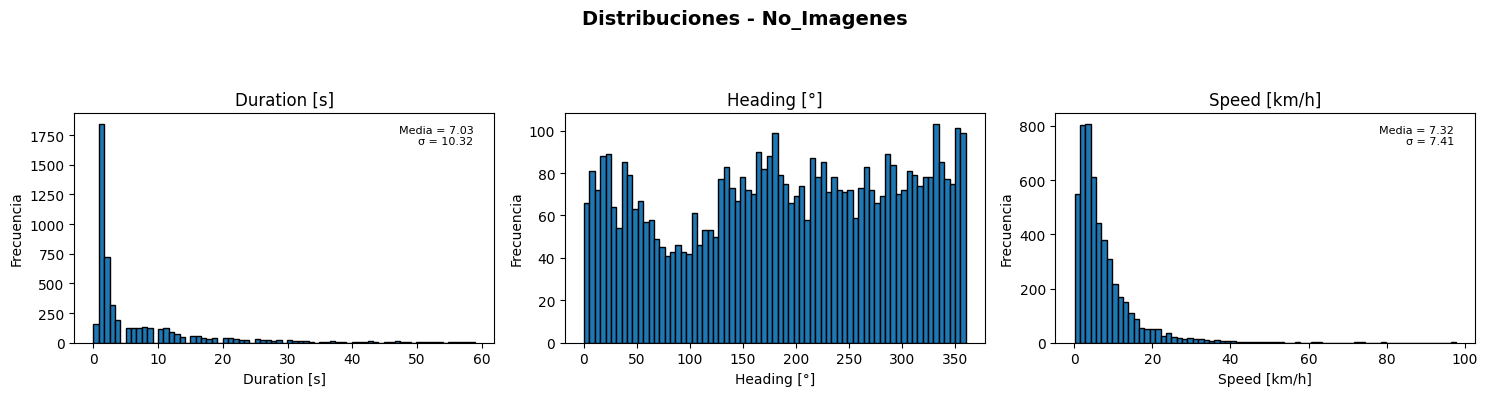

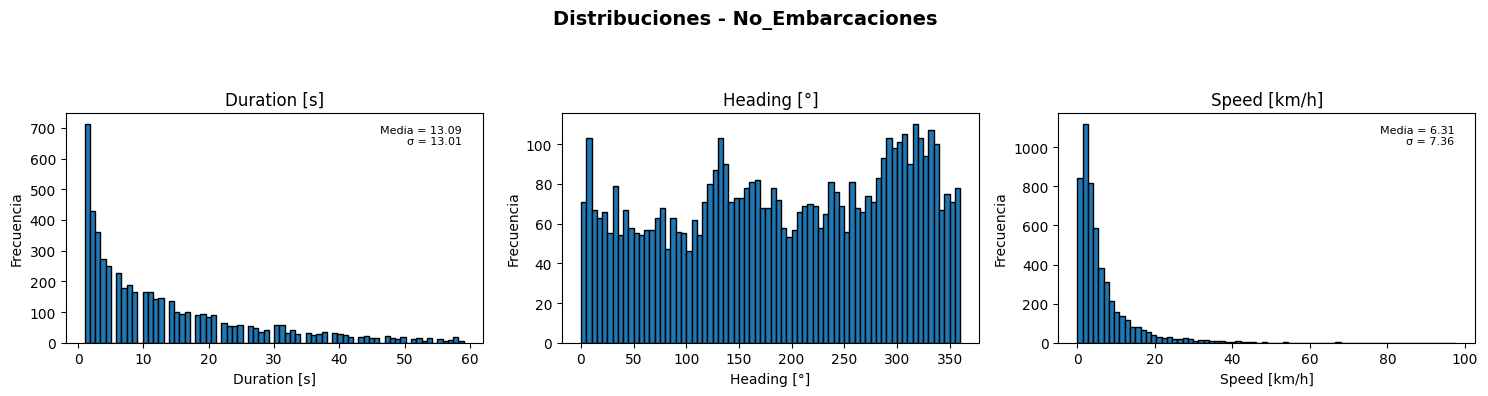

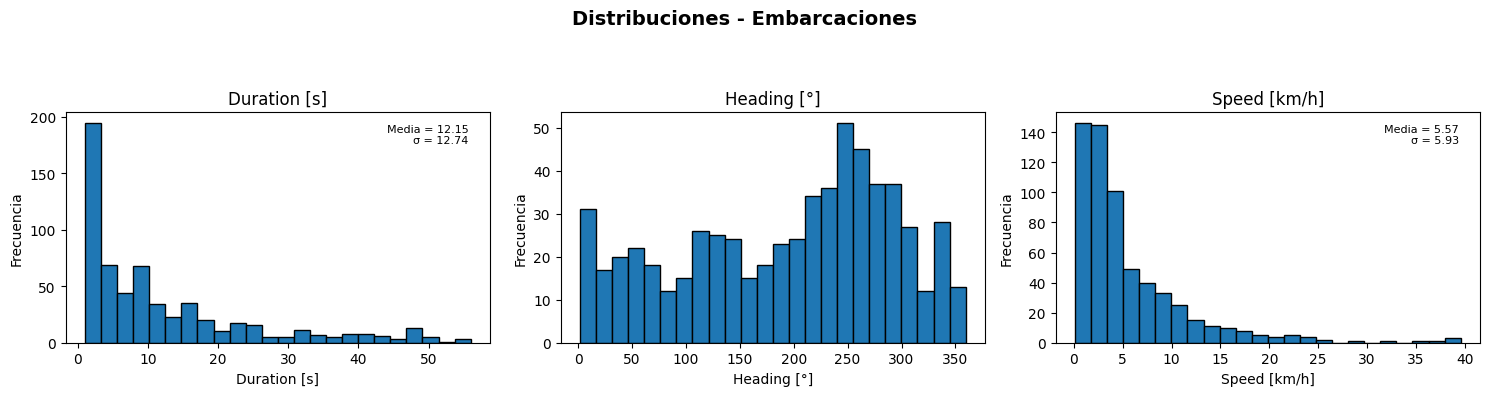

In [4]:
# ---------------- Variables -------------------------------------------------------------------------------
Ruta_DB = os.path.normpath(os.path.join("..", "..", "..", "DB_Embarcaciones.csv"))                      # Ruta de la base de datos
Ruta_Salida = os.path.normpath(os.path.join("..", "..", ".."))                                          # Ruta de salida de los archivos generados

# Estructura base de la base de datos
campos = ['Duration [s]', 'Latitude', 'Longitude', 'Heading [°]', 'Speed [km/h]', 'System_Time']        # Campos a extraer de la base de datos
Database = {k: {c: [] for c in campos} for k in ["No_Imagenes", "No_Embarcaciones", "Embarcaciones"]}   # Diccionario para almacenar los datos clasificados

# Contadores y registros de control
Registros_Repetidos_No_Embarcaciones = 0
Registros_Repetidos_Embarcaciones = 0
track_subs = Counter()
pair_counts = Counter()

# ---------------- Extracción de resultados ---------------------------------------------------------------
registros_vistos = set()
registros_vistos_Aux = set()

with open(Ruta_DB, mode="r", newline='', encoding='utf-8') as infile:   # Abrir el archivo CSV de la base de datos
    reader = csv.DictReader(infile)                                     # Crear un lector de CSV como un diccionario
    header = reader.fieldnames                                          # Obtener los nombres de las columnas del encabezado

    for row in reader:                                                  # Iterar sobre cada fila del archivo CSV           
        clave_unica = (row['Track_ID'], row['Sub_ID'])                  # Generar clave única combinando Track_ID y Sub_ID

        if clave_unica in registros_vistos:                             # Evitar duplicados y contar repeticiones
            if row['Main_Label'] == '0':
                Registros_Repetidos_No_Embarcaciones += 1               # Contar registros repetidos sin embarcaciones
            elif row['Main_Label'] == '1':
                Registros_Repetidos_Embarcaciones += 1                  # Contar registros repetidos con embarcaciones
            continue
        registros_vistos.add(clave_unica)                               # Marcar el registro como visto

        # ---------------- Clasificación de registros -------------------------------------------------------
        if row['Image_Name'] == 'N/A':
            categoria = "No_Imagenes"
        elif row['Main_Label'] == '0':
            categoria = "No_Embarcaciones"
        else:
            categoria = "Embarcaciones"

        # ---------------- Almacenamiento de valores --------------------------------------------------------
        Database[categoria]['Duration [s]'].append(extract_number(row['Duration']))
        Database[categoria]['Latitude'].append(extract_number(row['Latitude']))
        Database[categoria]['Longitude'].append(extract_number(row['Longitude']))
        Database[categoria]['Heading [°]'].append(extract_number(row['Heading']))
        Database[categoria]['Speed [km/h]'].append(extract_number(row['Speed']))
        Database[categoria]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


# ---------------- Cálculo de métricas --------------------------------------------------------------------
Correos_Sin_Imagenes = len(Database['No_Imagenes']['Duration [s]'])
Correos_Sin_Embarcaciones = len(Database['No_Embarcaciones']['Duration [s]'])
Correos_Con_Embarcaciones = len(Database['Embarcaciones']['Duration [s]'])

Total_Correos = Correos_Sin_Imagenes + Correos_Sin_Embarcaciones + Correos_Con_Embarcaciones
Total_Imagenes = (Correos_Sin_Embarcaciones + Registros_Repetidos_No_Embarcaciones +
                  Correos_Con_Embarcaciones + Registros_Repetidos_Embarcaciones)

# ---------------- Reporte general ------------------------------------------------------------------------
print(f"La base de datos contiene un aproximado de {Total_Correos} correos diferentes")
print(f"La cantidad de correos sin imágenes son: {Correos_Sin_Imagenes}, corresponde a un {round(Correos_Sin_Imagenes * 100 / Total_Correos, 3)}% de los correos\n")

print(f"La cantidad de correos con imágenes son: {Correos_Sin_Embarcaciones + Correos_Con_Embarcaciones}, corresponde a un {round((Correos_Sin_Embarcaciones + Correos_Con_Embarcaciones) * 100 / Total_Correos, 3)}% de los correos")
print(f"Los correos con imágenes pero sin embarcaciones son: {Correos_Sin_Embarcaciones}, corresponde a un {round(Correos_Sin_Embarcaciones * 100 / Total_Correos, 3)}% de los correos")
print(f"Los correos con imágenes y con embarcaciones son: {Correos_Con_Embarcaciones}, corresponde a un {round(Correos_Con_Embarcaciones * 100 / Total_Correos, 3)}% de los correos\n")

print(f"En total se disponen de {Correos_Sin_Embarcaciones + Registros_Repetidos_No_Embarcaciones} imágenes sin embarcaciones")
print(f"En total se disponen de {Correos_Con_Embarcaciones + Registros_Repetidos_Embarcaciones} imágenes con embarcaciones")
print(f"Se obtuvieron un total de {Total_Imagenes} imágenes\n")

# ---------------- Generación de histogramas ---------------------------------------------------------------
with PdfPages(os.path.normpath(os.path.join(Ruta_Salida, "histogramas_DB.pdf"))) as pdf:
    for categoria, variables in Database.items():
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Distribuciones - {categoria}", fontsize=14, fontweight="bold")

        columnas = ["Duration [s]", "Heading [°]", "Speed [km/h]"]

        for idx, nombre_var in enumerate(columnas):
            ax = axs[idx]
            valores = [v for v in variables.get(nombre_var, []) if v is not None]

            if len(valores) > 0:
                ax.hist(valores, bins=int(math.sqrt(len(valores))), edgecolor="black")
                ax.set_title(nombre_var)
                ax.set_xlabel(nombre_var)
                ax.set_ylabel("Frecuencia")

                # Calcular y mostrar estadísticas básicas
                if nombre_var in ["Duration [s]", "Speed [km/h]"] and len(valores) > 1:
                    media = stats.mean(valores)
                    sigma = stats.stdev(valores)
                    ax.text(
                        0.95, 0.95,
                        f"Media = {media:.2f}\nσ = {sigma:.2f}",
                        ha="right", va="top",
                        transform=ax.transAxes,
                        fontsize=8,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                    )
            else:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
                ax.set_title(nombre_var)

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()
        pdf.savefig(fig)
        plt.close(fig)

# Evaluacion temporal de los resultados de la base de datos

El objetivo del siguiente segmento de codigo es procesar los resultados obtenidos de la base de datos teniendo en cuenta la temporalidad de los correos.


Promedio y desviación estándar de correos por día (solo días con correos):
- No_Imagenes: media = 126.90, std = 179.98
- No_Embarcaciones: media = 146.67, std = 219.81
- Embarcaciones: media = 19.06, std = 34.14

Promedio y desviación estándar de imágenes por día (solo días con imágenes):
- No_Embarcaciones: media = 381.06, std = 1412.24
- Embarcaciones: media = 58.66, std = 223.83
- Total_Imagenes: media = 433.19, std = 1621.12


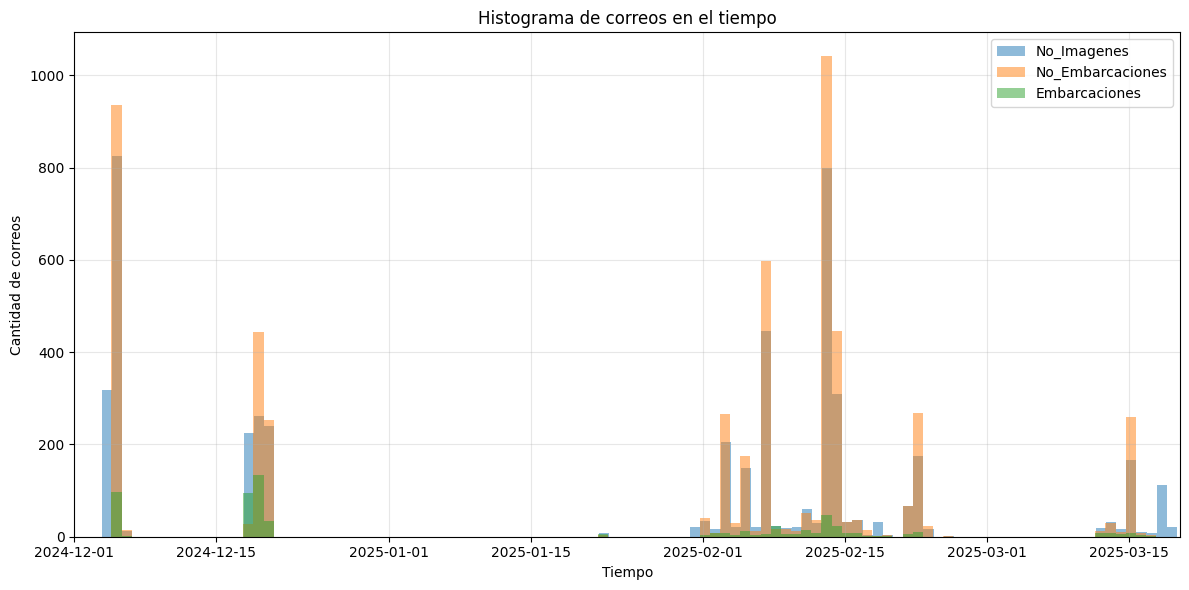

In [5]:
# ---------------- Configuración de la figura --------------------------------------------------------------
plt.figure(figsize=(12, 6))
estadisticas = {}
estadisticas_imagenes = {}

# ---------------- Procesamiento general (correos por día) ------------------------------------------------
for categoria, datos in Database.items():
    if len(datos["System_Time"]) == 0:
        continue

    times = pd.to_datetime(datos["System_Time"], errors='coerce').dropna()
    if times.empty:
        continue

    # Conteo diario de registros
    conteo_diario = times.to_series().dt.date.value_counts().sort_index()

    # Media y desviación estándar
    media = conteo_diario.mean()
    std = conteo_diario.std()
    estadisticas[categoria] = (media, std)

    # Histograma (un bin por día)
    plt.hist(
        times,
        bins=pd.date_range(start=times.min(), end=times.max(), freq='D'),
        alpha=0.5,
        label=categoria
    )

# ---------------- Estadísticas de imágenes (con y sin embarcaciones) -------------------------------------
if len(Database["No_Embarcaciones"]["System_Time"]) > 0:
    times_no_emb = pd.to_datetime(Database["No_Embarcaciones"]["System_Time"], errors='coerce').dropna()
    if not times_no_emb.empty:
        conteo_no_emb = times_no_emb.to_series().dt.date.value_counts().sort_index()
        if Registros_Repetidos_No_Embarcaciones > 0 and not conteo_no_emb.empty:
            conteo_no_emb.iloc[-1] += Registros_Repetidos_No_Embarcaciones
        estadisticas_imagenes["No_Embarcaciones"] = (
            conteo_no_emb.mean(),
            conteo_no_emb.std()
        )

if len(Database["Embarcaciones"]["System_Time"]) > 0:
    times_emb = pd.to_datetime(Database["Embarcaciones"]["System_Time"], errors='coerce').dropna()
    if not times_emb.empty:
        conteo_emb = times_emb.to_series().dt.date.value_counts().sort_index()
        if Registros_Repetidos_Embarcaciones > 0 and not conteo_emb.empty:
            conteo_emb.iloc[-1] += Registros_Repetidos_Embarcaciones
        estadisticas_imagenes["Embarcaciones"] = (
            conteo_emb.mean(),
            conteo_emb.std()
        )

# Total imágenes (suma de ambas)
if "No_Embarcaciones" in estadisticas_imagenes and "Embarcaciones" in estadisticas_imagenes:
    total_series = conteo_no_emb.add(conteo_emb, fill_value=0)
    estadisticas_imagenes["Total_Imagenes"] = (
        total_series.mean(),
        total_series.std()
    )

# ---------------- Resultados en consola ------------------------------------------------------------------
print("\nPromedio y desviación estándar de correos por día (solo días con correos):")
for categoria, (media, std) in estadisticas.items():
    print(f"- {categoria}: media = {media:.2f}, std = {std:.2f}")

print("\nPromedio y desviación estándar de imágenes por día (solo días con imágenes):")
for categoria, (media, std) in estadisticas_imagenes.items():
    print(f"- {categoria}: media = {media:.2f}, std = {std:.2f}")

# ---------------- Visualización ----------------------------------------------------------------------------
plt.xlim(pd.Timestamp("2024-12-01"), pd.Timestamp("2025-03-20"))
plt.title("Histograma de correos en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de correos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------- Configuración del área de interés ------------------------------------------------------
center_lat, center_lon = -3.805534, -70.306282                                      # Coordenadas centrales (Amazonas)
lat_margin, lon_margin = 0.002, 0.002                                               # Margen en grados (~200m)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)        # Transformador de coordenadas
minx, miny = transformer.transform(center_lon - lon_margin, center_lat - lat_margin)# Coordenadas mínimas en EPSG:3857
maxx, maxy = transformer.transform(center_lon + lon_margin, center_lat + lat_margin)# Coordenadas máximas en EPSG:3857

# Descargar mapa base desde OpenStreetMap
img, ext = ctx.bounds2img(minx, miny, maxx, maxy, zoom=19, source=ctx.providers.OpenStreetMap.Mapnik)

# ---------------- Preparación de los datos ---------------------------------------------------------------
points, categories = [], []
for key, data in Database.items():                                                              # Iterar sobre cada categoría y sus datos
    points.extend(Point(lon, lat) for lat, lon in zip(data['Latitude'], data['Longitude']))     # Crear puntos geográficos
    categories.extend([key] * len(data['Latitude']))                                            # Asignar categoría a cada punto

gdf = gpd.GeoDataFrame({'category': categories}, geometry=points, crs='EPSG:4326')              # Crear GeoDataFrame con sistema de referencia EPSG:4326
gdf_web = gdf.to_crs(epsg=3857).cx[minx:maxx, miny:maxy]                                        # Transformar a EPSG:3857 y recortar al área de interés

# ---------------- Configuración de visualización ----------------------------------------------------------
cmap_dict = {'No_Imagenes': 'Reds', 'No_Embarcaciones': 'Blues', 'Embarcaciones': 'Greens'}     # Colores para cada categoría
categories_unique = gdf_web['category'].unique()                                                # Categorías únicas en los datos

fig, axes = plt.subplots(1, len(categories_unique), figsize=(18, 6), squeeze=False)             # Crear subplots para cada categoría
axes = axes[0]                                                                                  # aplanar

# ---------------- Generación de mapas de calor ------------------------------------------------------------
gridsize = 50  # resolución de celdas

for ax, cat in zip(axes, categories_unique):
    subset = gdf_web[gdf_web['category'] == cat]
    if subset.empty:
        ax.set_visible(False)
        continue

    x, y = subset.geometry.x.values, subset.geometry.y.values
    H, xedges, yedges = np.histogram2d(x, y, bins=gridsize, range=[[minx, maxx], [miny, maxy]])

    # Índices de celdas y valores de densidad
    x_idx = np.clip(np.searchsorted(xedges, x) - 1, 0, gridsize - 1)
    y_idx = np.clip(np.searchsorted(yedges, y) - 1, 0, gridsize - 1)
    z = H[x_idx, y_idx]

    # Dibujar mapa base y dispersión coloreada por densidad
    ax.imshow(img, extent=ext, zorder=0)
    vmax = np.max(z) if len(z) else 1
    sc = ax.scatter(x, y, c=z, s=25, cmap=cmap_dict.get(cat, 'hot'), alpha=0.6, vmin=0, vmax=vmax)

    # Barra de color
    cbar = plt.colorbar(sc, ax=ax, label='Cantidad de correos', shrink=0.8)
    ticks = np.linspace(0, vmax, num=5)
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f"{int(t)}" for t in ticks])

    # Estética
    ax.set_axis_off()
    ax.set_title(cat)

# ---------------- Finalización ---------------------------------------------------------------------------
plt.tight_layout()
# plt.savefig("mapa_calor_scatter_cantidad_3categorias_max.png", dpi=300)
plt.show()

In [ ]:
# ---------------- Configuración de rutas -----------------------------------------------------------------
Ruta_Base = os.path.normpath(os.path.join("..", "..", ".."))
Nombre_DB = "DB_Embarcaciones.csv"
Nombre_Carpeta = "Imagenes_Embarcaciones"
Nombre_Modelo = os.path.normpath(os.path.join(
    "Model_Training", "YoloV11_Segmentation_Experimental-Result",
    "runs", "Modelo_416_Nano", "weights", "best.pt"
))

dir_path = os.path.normpath(os.path.join(Ruta_Base, Nombre_Carpeta))   # Carpeta principal de imágenes
db_path = os.path.normpath(os.path.join(Ruta_Base, Nombre_DB))         # Ruta al CSV de la DB
model_path = os.path.normpath(os.path.join(Ruta_Base, Nombre_Modelo))  # Ruta al peso del modelo
raw_path = os.path.join(dir_path, "Raw")                               # Carpeta para raw copies
yolo_path = os.path.join(dir_path, "Yolo")                             # Carpeta para imágenes con cajas

# ---------------- Inicialización del modelo -------------------------------------------------------------
# Intenta usar CUDA si está disponible; si no, usa CPU (evita fallos si no hay GPU)
try:
    model = YOLO(model_path)
    # mover a GPU solo si está disponible
    try:
        import torch
        if torch.cuda.is_available():
            model.to("cuda")
    except Exception:
        # si torch no está disponible o falla, seguimos con el modelo tal cual (modelo decide backend)
        pass
except Exception as e:
    raise RuntimeError(f"Error cargando el modelo en '{model_path}': {e}")

# ---------------- Creación de carpetas si no existen ---------------------------------------------------
os.makedirs(raw_path, exist_ok=True)
os.makedirs(yolo_path, exist_ok=True)

# ---------------- Lectura del CSV y procesamiento ------------------------------------------------------
count = 0  # contador de imágenes procesadas

with open(db_path, "r", encoding="utf-8", newline='') as infile:
    reader = csv.DictReader(infile)

    for row in reader:
        # Filtrar filas que no interesan (sin imagen o etiqueta distinta de 1)
        if row.get("Image_Name") == "N/A" or row.get("Main_Label") != "1":
            continue

        count += 1

        # Construir la ruta relativa y absoluta de forma robusta
        ruta_rel = os.path.normpath(f"{row.get('Path','')}\\{row.get('Image_Path','')}\\{row.get('Image_Name','')}")
        ruta = os.path.normpath(os.path.join(Ruta_Base, ruta_rel.split("..\\")[-1]))
        ext = os.path.splitext(ruta)[1]

        # --- Carga de la imagen y comprobación ---
        imagen = cv2.imread(ruta)
        if imagen is None:
            # Si no se puede leer la imagen (ruta errónea o archivo corrupto), saltar y continuar
            print(f"[WARN] No se pudo leer la imagen: {ruta}")
            continue

        # --- Predicción con YOLO ---
        try:
            predict = model(ruta, verbose=False)[0]  # obtener la predicción para la imagen
        except Exception as e:
            print(f"[WARN] Error al predecir con YOLO en '{ruta}': {e}")
            # Guardar copia raw aunque falle la predicción
            shutil.copy2(ruta, os.path.join(raw_path, f"{count}{ext}"))
            continue

        # --- Dibujo de cajas y confianzas si existen detecciones ---
        boxes = getattr(predict, "boxes", None)
        if boxes is not None and len(getattr(boxes, "xyxy", [])) > 0:
            # Convertir tensores a enteros y listas de forma segura
            try:
                xyxy_list = boxes.xyxy.int().tolist()
            except Exception:
                # si no es tensor, caer atrás a conversión estándar
                xyxy_list = [ [int(v) for v in box] for box in boxes.xyxy.tolist() ]

            confs = boxes.conf.tolist() if getattr(boxes, "conf", None) is not None else [0.0]*len(xyxy_list)

            # Dibujar rectángulos y textos sobre la imagen
            for (x1, y1, x2, y2), prob in zip(xyxy_list, confs):
                cv2.rectangle(imagen, (x1, y1), (x2, y2), (255, 229, 180), 2)
                cv2.putText(imagen, f"{prob:.2f}", (max(x1-15,0), max(y1-15,0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 100), 2)

        # --- Guardado de imágenes (raw y con anotaciones) ---
        try:
            shutil.copy2(ruta, os.path.join(raw_path, f"{count}{ext}"))
        except Exception as e:
            print(f"[WARN] Falló copia raw de '{ruta}' -> {e}")

        try:
            cv2.imwrite(os.path.join(yolo_path, f"{count}{ext}"), imagen)
        except Exception as e:
            print(f"[WARN] Falló escritura anotada para '{ruta}' -> {e}")

# ---------------- Resumen final ----------------------------------------------------------------------------
print(f"Total procesadas: {count}")


Total procesadas: 1877


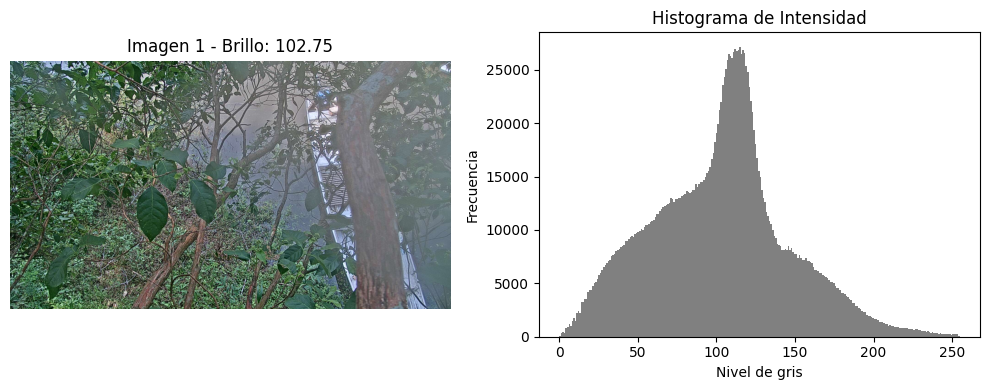

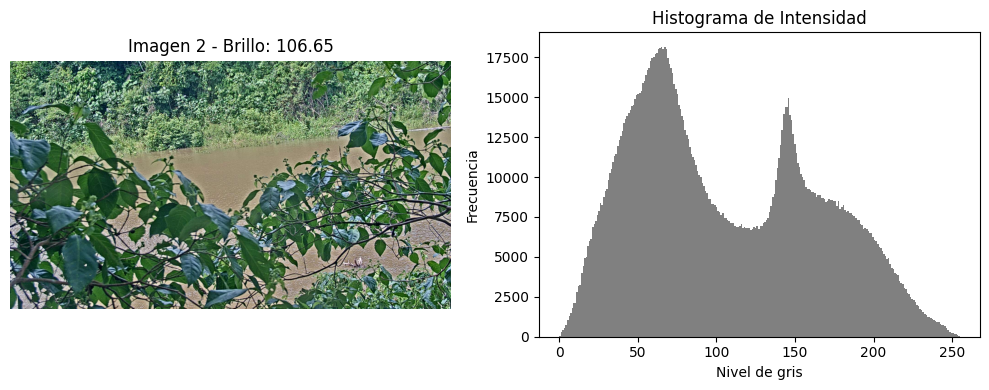

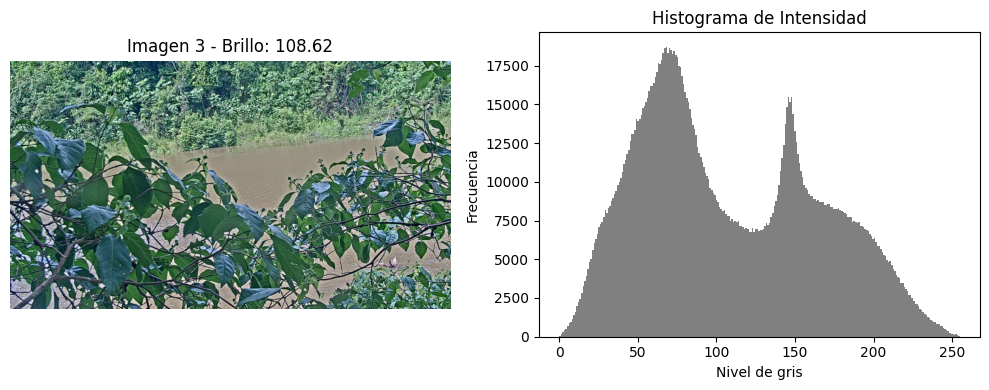

Se analizaron 15595 imágenes
Cantidad de imágenes nocturnas: 4303


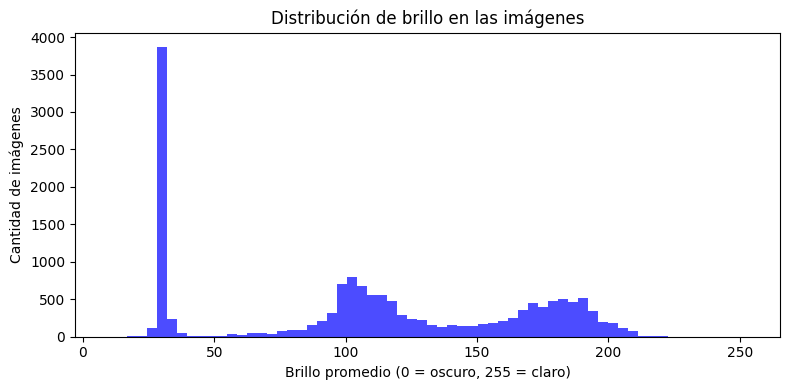

In [38]:
# ---------------- Variables / Rutas ----------------------------------------------------------------------
Ruta_Base = os.path.normpath(os.path.join("..", "..", ".."))              # Ruta base del proyecto
Nombre_DB = "DB_Embarcaciones.csv"                                        # Nombre del CSV
Nombre_Carpeta = "Imagenes_Embarcaciones_Noche"                           # Carpeta destino para nocturnas

dir_path = os.path.join(Ruta_Base, Nombre_Carpeta)                        # Ruta completa destino
db_path = os.path.join(Ruta_Base, Nombre_DB)                              # Ruta completa CSV

# ---------------- Inicialización ------------------------------------------------------------------------
brillos = []              # Lista de brillos promedio por imagen
count = 0                 # Contador total de imágenes procesadas
count_noche = 0           # Contador de imágenes clasificadas como noche

os.makedirs(dir_path, exist_ok=True)  # Crear carpeta si no existe

# ---------------- Lectura y procesamiento del CSV -------------------------------------------------------
with open(db_path, "r", newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)

    for row in reader:
        # Saltar filas sin imagen
        if row.get("Image_Name") == "N/A":
            continue

        count += 1

        # Construir ruta a la imagen de forma robusta
        ruta_rel = os.path.normpath(f"{row['Path']}\\{row['Image_Path']}\\{row['Image_Name']}")
        ruta = os.path.normpath(os.path.join(Ruta_Base, ruta_rel.split("..\\")[-1]))
        ext = os.path.splitext(ruta)[1]

        # Leer imagen; si falla, continuar
        imagen = cv2.imread(ruta)
        if imagen is None:
            continue

        # ---------------- Conversión a gris y cálculo de brillo ---------------------------------------
        gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
        brillo_prom = float(np.mean(gris))      # Brillo promedio (0-255)
        brillos.append(brillo_prom)

        # ---------------- Visualizar primeros ejemplos ------------------------------------------------
        if count <= 3:
            plt.figure(figsize=(10, 4))

            # Imagen RGB
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
            plt.title(f"Imagen {count} - Brillo: {brillo_prom:.2f}")
            plt.axis("off")

            # Histograma de intensidades (niveles de gris)
            plt.subplot(1, 2, 2)
            plt.hist(gris.ravel(), bins=256, color='gray')
            plt.title("Histograma de Intensidad")
            plt.xlabel("Nivel de gris")
            plt.ylabel("Frecuencia")
            plt.tight_layout()
            plt.show()

        # ---------------- Clasificación noche / copia --------------------------------------------------
        # Si el brillo está por debajo del umbral, copiar a carpeta de nocturnas
        if brillo_prom < 50:
            count_noche += 1
            shutil.copy2(ruta, os.path.join(dir_path, f"{count}{ext}"))

# ---------------- Resultados y métricas ------------------------------------------------------------------
print(f"Se analizaron {count} imágenes")
print(f"Cantidad de imágenes nocturnas: {count_noche}")

# ---------------- Visualización final -------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(brillos, bins=64, color='blue', alpha=0.7)
plt.title("Distribución de brillo en las imágenes")
plt.xlabel("Brillo promedio (0 = oscuro, 255 = claro)")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()